<a href="https://colab.research.google.com/github/nacrocker/automated-segmentation/blob/max-burgers-branch/Maxs_maxtree_tests_with_synthetic_data_and_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Main Code

In [5]:
 # @title Machinery and Utilities - Run this cell up first opening notebook
# cell name: machinery_and_utilities
machinery_and_utilities=True

## begin synthetic_signal_machinery

import numpy as np
from scipy.signal import chirp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import Normalize
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.signal import ShortTimeFFT
import random as rng
import pandas as pd
import scipy.linalg
import scipy.sparse.linalg
import scipy.stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1
#helps taper ft data at the ends where gibbs phenomena occurs

#def make_noise(mean, std, shape, noise_generator = np.random.normal):
def getSavedRndGenSeed():
    global SavedRndGenSeed
    if not 'SavedRndGenSeed' in globals():
        SavedRndGenSeed = np.random.SeedSequence()
    return SavedRndGenSeed
    #makes sure random number reproducibility is possible


def make_noise(mean=0.0, std=1.0, shape=None, noise_generator = None, seed = None):
    if noise_generator is None: noise_generator = np.random.default_rng(seed=seed).normal
    return noise_generator(mean, std, shape)
    #generates array of random numbers based on a mean, std, and shape
    #shape of output array is (n,)

import typing
class Chirp(typing.NamedTuple):
    amp: float = 1.0
    envlf: typing.Callable[...,typing.Any] = blackman_vs_tau
    t0: float = 0.0  #seconds
    t1: float = 1.0  #seconds
    f0: float = 1000.0 #Hz
    f1: float  = 11000.0 #Hz
    phi: float = 0.0 #degrees
    method: str = 'quadratic'
    vertex_zero: bool = True

    def __call__(self,t):
        """make chirp, c(t):
           t:  array-like float
           for t such that self.t0 <= t <= self.t1:
               c(t) = amp*envlf((t-self.t0)/(self.t1-self.t0))*
               scipy.signal.chirp(t-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
               where envlf is a continuous function that defines values for 0<= t <= 1.
                   the default, blackman_vs_tau, is inspired by the blackmann window where, for 0 <= t <= 1:
                   blackman_vs_tau(t) = 0.42 + 0.5*cos(2*np.pi*(t-0.5)) + 0.08*cos(4*np.pi*(t-0.5))
              self.method defaults to quadratic and self.vertex_zero defaults to true.
           for t such that t <=self.t0 or self.t1 <= t: c(t) = 0
        """
        import numpy as np
        from scipy.signal import chirp
        t = np.asarray(t).flatten()
        nt = t.size
        sig=np.zeros((nt,),dtype=float)
        it0 = np.searchsorted(t,self.t0)
        it1 = np.searchsorted(t,self.t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=self.envlf((t[it0:it0+ntch]-self.t0)/(self.t1-self.t0))
            sig[it0:it0+ntch] = self.amp*envl*chirp(t[it0:it0+ntch]-self.t0, self.f0, self.t1-self.t0, self.f1, method=self.method, phi=self.phi, vertex_zero=self.vertex_zero)
        return sig
        #allows one to treat chirp objects as functions

def add_funcsigs(sigfunclist,t):
    sig = 0.0
    for sgf in sigfunclist: sig+=sgf(t)
    return sig
    #sums multiple signals together


## end synthetic signal machinery

## begin max_tree_machinery

class Cached_Computed_Attributes:
    '''mixin class with methods for managing cached computed attributes'''

    @staticmethod
    def cached_computed_attribute(attribute_name):
        def cached_computer_attribute_decorator(attribute_compute_method):

            def attribute_compute_method_with_caching(self):
                if self.is_cached(attribute_name):
                    ret = self.get_cached(attribute_name)
                    if not (ret is None): return ret

                attribute = attribute_compute_method(self)

                self.cache(attribute_name,attribute)
                return attribute

            return property(attribute_compute_method_with_caching)
        return cached_computer_attribute_decorator


    _listy_types = (list, tuple)
    def cache(self,attr,val):
        """Cache a computed attribute"""
        if (attr,str):
            setattr(self,'_'+attr,val)
            self._cached[attr]=attr
            return None

    @property
    def cached(self):
        """Get dictionary of cached computed attributes."""
        return {k:getattr(self,'_'+k) for k in self._cached.keys()}

    def list_cached(self):
        """Get names of cached computed attributes."""
        return self._cached.keys()

    def is_cached(self,attr):
        """Test if attribute or list of attribures is cached"""
        if isinstance(attr,self.__class__._listy_types):
            return [self.is_cached(a) for a in attr]

        if isinstance(attr,str):
            return attr in self._cached and hasattr(self,'_'+attr)

        #if this point is reached, something is wr

    def add_alias_to_cached(self,attr,alias):
        """Add alias or list of alias to attributes"""

        if isinstance(attr,self.__class__._listy_types) and isinstance(alias,self.__class__._listy_types) and len(attr) == len(alias):
            for a,al in zip(attr,alias): self.add_alias_to_cached(a,al)
            return None

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            self._cached[alias] = attr
            return None

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names.')


    def is_alias_to_cached(self,attr):
        """Test if atrributes are aliass to other attributes."""
        if isinstance(attr,_listy_types):
            return [self.is_alias_to_cached(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return attr == self._cached[attr]

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute be name or list of attribute names.')


    def dereference_alias(self,attr):
        """Dereference aliases to cached computed attributes. Non-aliases will deference to themselves."""
        if isinstance(attr,self.__class__._listy_types):
            return [self.dereference_alias(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return self._cached[attr]

        #if this point is reached, something is wrong.
        raise ValueError('attr should attribute name or list of attribute names.')


    def get_cached(self,attr):
        """Get cached computed attribute values"""
        if isinstance(attr,self.__class__._listy_types):
            return [self.get_cached(a) for a in attr]

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            return getattr(self,'_'+attr)

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names.')


    def clear_cached(self,attr=None,all=False):
        """Clear cached computed attributes by name or list of names, or all by all=True."""
        def _safe_clear_cached(attr):
            if hasattr(self,'_'+attr): delattr(self,'_'+attr)
            if attr in self._cached: self._cached.pop(attr)

        if attr is None: return None

        if all:
            for a in attr: self.clear_cached(a)
            return None

        if isinstance(attr,self.__class__._listy_types):
            for a in attr: self.clear_cached(a)
            return None

        if isinstance(attr,str):
            if self.is_cached(attr) is None: raise KeyError(attr)
            _safe_clear_cached(attrs)
            return None

        #if this point is reached, something is wrong.
        raise ValueError('attr should be attribute name or list of attribute names, or all=True should be provided.')


class Max_Tree(Cached_Computed_Attributes):
    import numpy as np

    def __init__(self,image=None,connectivity=1):
        self._cached={}
        self._connectivity = connectivity
        if image is None:
            self._image=None
            self._connectivity=None
            self._P=None
            self._S=None
            return
        from skimage.morphology import max_tree as max_tree_ski
        self._image = image
        self._P,self._S = max_tree_ski(image, connectivity=self._connectivity)


    @property
    def image(self):
        """Get the max_tree image"""
        return self._image

    @property
    def intensity(self):
        """Get the max_tree image""" #check this later
        return self._image

    @property
    def P(self):
        """Get the max_tree parent matrix"""
        return self._P

    @property
    def S(self):
        """Get the max_tree traverser array"""
        return self._S

    @property
    def parent(self):
        """Get max_tree parent matrix"""
        return self.P

    @property
    def sorted_indices(self):
        """Get max_tree sorted_indices array"""
        return self.S

    @property
    def connectivity(self):
        """Get the max_tree connectivity."""
        return self._connectivity

    cached_computed_attribute=Cached_Computed_Attributes.cached_computed_attribute

    @cached_computed_attribute('C')
    def C(self):
        S = self.S
        P_rav = self.P.ravel()
        C_rav = [[] for _ in range(len(P_rav))]
        C = np.empty(self.image.shape,dtype=list)
        for p in S[1:]:
            q = P_rav[p]
            C_rav[q].append(p)
        C.ravel()[:]= C_rav[:]
        return C

    @cached_computed_attribute('children')
    def children(self):
        return self.C

    @cached_computed_attribute('canonicality')
    def canonicality(self):
        """Get the canonicality of each position in P, the parent matrix. i.e. whether it represents a component"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        canonicality_rav = image_rav != image_rav[parent]
        p_root = sorted_indices[0]
        canonicality_rav[p_root] = True
        canonicality = np.reshape(canonicality_rav,self.P.shape)

        return canonicality

    @cached_computed_attribute('numcomponents')
    def numcomponents(self):
        """Get the number of components."""
        if self._image is None: return None

        numcomponents = np.sum(self.canonicality)
        return numcomponents


    @cached_computed_attribute('sorted_labels')
    def sorted_labels(self):
        """Get the component labels for each of the node in S, the sorted_indices array.
        Non-canonical nodes have a value equal to the negative of their canonical parent label.
        Label magnitudes increase from 0 starting at beginning of sorted_labels. """
        if self._image is None: return None

        sorted_labels=np.cumsum(self.canonicality[self.S])
        sorted_labels[~self.canonicality[self.S]] *= -1
        return sorted_labels

    @cached_computed_attribute('labels')
    def labels(self):
        """Get the component labels for each of the node in P, the parent matrix.
        Non-canonical nodes have a value equal to the negative of their canonical parent label."""
        if self._image is None: return None

        labels = self._P.copy()
        labels.ravel()[self.S] = self.sorted_labels

    @cached_computed_attribute('component_P_indices')
    def component_P_indices(self):
        """Get the indices (aka P-indices) in P, or the parent matrix, for the node correposonding to component to which the node belongs.
        For a canonical node, component_P_indices.ravel()[i] == i."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        indices=np.reshape(np.arange(parent.size),self.P.shape)
        indices_rav=indices.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]: indices_rav[p]=indices_rav[q]

        return indices

    @cached_computed_attribute('order')
    def order(self):
        """Get the position within S, the sorted_indices array, of nodes in P, the parent matrix.
        In other words, for a node i in P.ravel(), S[order[i]] == i"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        order = np.argsort(self.sorted_indices)

        return order

    @cached_computed_attribute('order_P_indices')
    def order_P_indices(self):
        """Get the order within S, the sorted_indices array, of the P-indices (component indices in P).
        For a canonical node i in P.ravel(), S[order_P_indices[i]] == i.
        For a non-canoncical node i in P.ravel(), S[order_P_indices[i]] == P.ravel[i]"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        order = self.order

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]:
                order[p] = order[q]

        return order


    @cached_computed_attribute('numchildren')
    def numchildcomponents(self):
        """Get the number of child components for each comoenent node.
        Non-canonical nodes will have values which are the negative of the number of components for their parent component node."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        numchildren = np.zeros(image.shape, dtype=int)
        numchildren_rav=numchildren.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] != image_rav[p]:
                numchildren_rav[q] += 1

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[q] == image_rav[p]:
                numchildren_rav[p] = -numchildren_rav[q]

        return numchildren

    @cached_computed_attribute('numchildnodes')
    def numchildnodes(self):
        """Get the number of children in the max-tree for each tree node (count includes non-canonical nodes)."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        numchildren = np.zeros(image.shape, dtype=int)
        numchildren_rav=numchildren.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            numchildren_rav[q] += 1

        return numchildren

    @cached_computed_attribute('leaf_P_indices')
    def leaf_P_indices(self):
        """Get the P-indices of component leaf nodes. (Note that non-canonical nodes are leaf nodes but not component leave nodes.)"""
        if self._image is None: return None

        return np.flatnonzero(self.numchildnodes == 0)

    @property
    def leaves(self):
        """Alias for leaf_P_indices"""
        return self.leaf_P_indices

    @cached_computed_attribute('sorted_leaf_P_indices')
    def sorted_leaf_P_indices(self):
        """Get the P-indices ??? of component leaf nodes. (Note that non-canonical nodes are leaf nodes but not component leaf nodes.)"""
        if self._image is None: return None

        return self.S[np.flatnonzero(self.numchildnodes.ravel()[self.S] == 0)]

    @cached_computed_attribute('peak')
    def peak(self):
        """Get the peak (max intensity) for each component."""
        if self._image is None: return None

        image = self._image
        parent = self._P.ravel()
        sorted_indices = self._S

        peak = image.copy()

        image_rav = image.ravel()
        peak_rav = peak.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[p] != image_rav[q]:
                peak_rav[q] = max(peak_rav[p], peak_rav[q])  # search maximum and propagate maximum to parent node
            else:
                # canonicalize value. this works because the sort_indices order will cause all
                # canonical children of q to be reached before non-canonical children
                peak_rav[p] = peak_rav[q]
        return peak



    @property
    def contrast(self):
        """Get the contrast for each component. contrast=max_over_component(intensity)/min_over_component(intensity)"""
        if self._image is None: return None

        contrast = ((self.peak).copy()).astype(np.float64)/self._image

        return contrast


    @property
    def log_contrast(self):
        """Get the log of contrast for each component. logContrast = log(max_over_component(intensity)) - log(min_over_component(intensity))."""
        if self._image is None: return None

        log_contrast = np.log(((self.peak).copy()).astype(np.float64))-np.log(self._image)

        return log_contrast


    @cached_computed_attribute('height')
    def height(self):
        """Get the height for each component.  Height = max_over_component(intensity)-min_over_component(intensity)"""
        if self._image is None: return None

        height = ((self.peak).copy()).astype(np.float64)-self._image

        return height

    @cached_computed_attribute('area')
    def area(self):
        """Get the area (number of pixels) for each component."""
        if self._image is None: return None

        image = self._image #creates freq/time spectrogram
        image_rav = image.ravel() #make image an array
        parent = self._P.ravel() #get the parent indices of each pixel
        sorted_indices = self._S #each pixel is preceeded by its parent, so the leaves are at the end

        area = np.ones(image.shape, dtype=int) #initialize grid of ones
        area_rav=area.ravel() #turn into array

        for p in sorted_indices[:0:-1]: #go through sorted indices (p) back wards, so top of tree first
            q = parent[p] #q is then the parent of p
            area_rav[q] += area_rav[p] #area of the parent pixel = it's area plus the area of it's leaf

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]: #if a pixel and it's parent are the same
                area_rav[p] = area_rav[q] # canonicalize value

        return area



    @cached_computed_attribute('volume')
    def volume(self):
        """Get the volume for each component. Volume = sum_over_component(intensity-min_over_parent_component(intensity))"""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        area = self.area
        area_rav=area.ravel()

        volume = np.zeros(image.shape, dtype=np.float64)
        volume_rav=volume.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            if image_rav[p] != image_rav[q]:
                volume_rav[q] += area_rav[p]*(image_rav[p]-image_rav[q])+volume_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                volume_rav[p] = volume_rav[q] # canonicalize value

        return volume


    @cached_computed_attribute('r_squared')
    def r_squared(self):
        """Get r_squared for each component"""
        if self._image is None: return None

        image = self._image #original image
        image_rav = image.ravel() #ravelled image
        parent = self._P.ravel() #ravelled matrix where each value is the index of it's parent in ravelled array
        sorted_indices = self._S #array where pixels are ordered such that each pixel is preceeded by it's parents and each value is the ravelled image index

        volume = np.zeros(image.shape, dtype=np.float64)
        volume_rav=volume.ravel()

        for p in sorted_indices[:0:-1]: # traverse through ordered mt components from leave to root
            q = parent[p] #index of the parent of the pixel p
            if image_rav[p] != image_rav[q]: #if pixel p's gain not equal to parent's gain
                volume_rav[q] += area_rav[p]*(image_rav[p]-image_rav[q])+volume_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                volume_rav[p] = volume_rav[q] # canonicalize value

        return volume



    @cached_computed_attribute('total_image')
    def total_image(self):
        """Get the total_image (sum of image values) for each component."""
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        total_image = np.copy(image)
        total_image_rav=total_image.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            total_image_rav[q] += total_image_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                total_image_rav[p] = total_image_rav[q] # canonicalize value

        return total_image

    @property
    def total_intensity(self):
        """Get the total_intensity (sum of intensities) for each component."""
        return self.total_image

    @cached_computed_attribute('intensity_entropy')
    def image_entropy(self):
        """Get the entropy for each component, -sum(total_image_fraction*log(total_image_fraction)), where total_image_fraction = (image value)/total_image """
        if self._image is None: return None

        image = self._image
        image_rav = image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        image_entropy = -image*np.where(image > 0,np.log(image),0)
        image_entropy_rav=image_entropy.ravel()

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            image_entropy_rav[q] += image_entropy_rav[p]

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                image_entropy_rav[p] = image_entropy_rav[q] # canonicalize value

        image_entropy = (lambda a,n: a/n + np.log(n))(image_entropy,self.total_image)
        return image_entropy

    @property
    def intensity_entropy(self):
        """Get the entropy for each component, -sum(total_intensity_fraction*log(total_intensity_fraction)), where total_intensity_fraction = intensity/total_intensity """
        return self.image_entropy

    @cached_computed_attribute('extents')
    def extents(self):
        """Get the extent (index ranges for each coordinate) for each component."""
        if self._image is None: return None

        image = self._image
        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S

        number_of_pixels = np.size(image)

        max_coord = np.array(np.unravel_index(np.arange(number_of_pixels), image.shape)).T
        min_coord = np.array(np.unravel_index(np.arange(number_of_pixels), image.shape)).T
        extents = np.ones((*image.shape,2),dtype=int)
        extents_rav = extents.reshape((number_of_pixels,2))

        for p in sorted_indices[:0:-1]:
            q = parent[p]
            max_coord[q] = np.maximum(max_coord[q], max_coord[p])
            min_coord[q] = np.minimum(min_coord[q], min_coord[p])
            extents_rav[q] = (max_coord[q] - min_coord[q]) + 1

        for p in sorted_indices[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                extents_rav[p] = extents_rav[q] # canonicalize value

        return extents

    @property
    def extension(self):
        """Get the maximum of all extents (index ranges for each coordinate) for each component."""
        if self._image is None: return None

        return np.max(self.extents,axis=2)

    @property
    def diameter(self):
        """Get diameter (alias for extension) for each component."""
        return self.extension


    def fill_components_from_markers(self,markers=None,unmarked=0,preserve_nesting=False):

        image = self._image
        if markers is None or not np.array_equal(markers.shape,image.shape):
            raise ValueError('markers should be matrix with same shape as image')

        image=self.image
        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        output = markers.copy()
        output_rav=output.ravel()

        if np.isnan(unmarked):
            for p in sorted_indices[:0:-1]:
                #if noncanonical node is marked, mark canonical parent
                q = parent[p]
                if image_rav[q] == imag_rav[p] and ~np.isnan(output_rav[p]): output_rav[q] = output_rav[p]

            for p in sorted_indices[1:]:
                q = parent[p]
                if ~np.isnan(output_rav[q]) and (not preserve_nesting or np.isnan(output_rav[p])) : output_rav[p] = output_rav[q]
        else:
            for p in sorted_indices[:0:-1]:
                #if noncanonical node is marked, mark canonical parent
                q = parent[p]
                if image_rav[q] == image_rav[p] and output_rav[p] != unmarked: output_rav[q] = output_rav[p]

            for p in sorted_indices[1:]:
                # is parent is marked, mark child.
                q = parent[p]
                if output_rav[q] != unmarked and (not preserve_nesting or output_rav[p] == unmarked): output_rav[p] = output_rav[q]

        return output


    def direct_filter(self,attribute='area',attribute_threshold=3):
        """Apply a direct filtering.

        This produces an image in which for all possible thresholds, each connected
        component has the specified attribute value greater than that threshold.
        This is the basic function called by :func:`area_opening`,
        :func:`diameter_opening`, and similar.

        For :func:`area_opening`, for instance, the attribute is the area.  In this
        case, an image is produced for which all connected components for all
        thresholads have at least an area (pixel count) of the threshold given by
        the user.

        Parameters
        ----------

        attribute : name of attribute or array of float with same shape as image
            that ontains the attributes computed for the max-tree.
        attribute_threshold : float
            The threshold to be applied to the attribute.

        Notes
        ----------
        Adapted from source code for skimage max_tree:
        https://github.com/scikit-image/scikit-image/blob/v0.25.2/skimage/morphology/_max_tree.pyx
        """

        image = self._image

        isvalidattr = False
        if isinstance(attribute,str) and hasattr(self,attribute):
                attrtemp=getattr(self,attribute)
                if np.array_equal(attrtemp.shape,image.shape):
                    attribute=attrtemp
                    isvalidattr = True
        else:
            if np.array_equal(attribute.shape,image.shape): isvalidattr = True

        if not isvalidattr:  raise ValueError('attr should be attribute name or array with same shape as image')


        image_rav=image.ravel()
        parent = self._P.ravel()
        sorted_indices = self._S
        attribute_rav=attribute.ravel()

        output = image.copy()
        output_rav=output.reshape((size(image),*output.shape[2:]))

        p_root = sorted_indices[0]
        if attribute_rav[p_root] < attribute_threshold:
            output_rav[p_root] = 0
        else:
            output_rav[p_root] = image_rav[p_root]

        for p in sorted_indices[1:]:
            q = parent[p]

            # this means p is not canonical
            # in other words, it has a parent that has the
            # same image value.
            if image_rav[p] == image_rav[q]:
                output_rav[p] = output_rav[q]
                continue

            if attribute_rav[p] < attribute_threshold:
                # this corresponds to stopping
                # as the level of the lower parent
                # is propagated to the current level
                output_rav[p] = output_rav[q]
            else:
                # here the image reconstruction continues.
                # The level is maintained (original value).
                output_rav[p] = image_rav[p]

        return output

    def maxattrclosing(self,attr,return_nodes=False):
        """propagates maxiumum attr value along lineage from root back to leaf. For non-monotonic attributes, this fills any valley between highest value descendenent and leaf"""
        image_rav = self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        maxattr = attr.copy()
        maxattr_rav=maxattr.ravel()
        if return_nodes:
            maxattrnodes = np.zeros(attr.shape,dtype=bool)
            maxattrnodes_rav = maxattrnodes.ravel()
            maxattrnodes_rav[S[0]] = True
            for p in S[1:]:
                q=parent[p]
                if image_rav[p] != image_rav[q]:
                    if maxattr_rav[p] >= maxattr_rav[q]:
                        #maxattr_rav[p] = maxattr_rav[p]
                        maxattrnodes_rav[p] = True
                        maxattrnodes_rav[q] = False
                    else:
                        maxattr_rav[p] = maxattr_rav[q]
                else:
                    maxattr_rav[p] = maxattr_rav[q] #canoicalize maxattr
            return (maxattr,maxattrnodes)
        else:
            for p in S[1:]:
                q=parent[p]
                if image_rav[p] != image_rav[q]:
                    maxattr_rav[p] = np.maximum(maxattr_rav[p],maxattr_rav[q])
                else:
                    maxattr_rav[p] = maxattr_rav[q] #canoicalize maxattr
            return maxattr

    def leafattrflatnodes(self,attr,attrthresh=None,mask=None):
        """marks nodes for components with flat attribute value around leaves (e.g. from area opening) """
        image_rav=self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        flatnodes = self.numchildnodes == 0 # will only mark true leaves, not non-canonical nodes.
        if not attrthresh is None: flatnodes = flatnodes & (attr >= attrthresh)
        if not mask is None: flatnodes = flatnodes & mask
        flatnodes_rav = flatnodes.ravel()
        attr_rav=attr.ravel()
        for p in S[:0:-1]:
            q=parent[p]
            if flatnodes_rav[p] and attr_rav[q] == attr_rav[p]:
                #move flatzone node marker to parent of flatzone
                flatnodes_rav[q] = True
                flatnodes_rav[p] = False
        return flatnodes

    def leafattrflatzones(self,attr,attrthresh=None,mask=None):
        """marks zones of flat attribute value around leaves (e.g. from area opening) """
        image_rav=self.image.ravel()
        S=self.S
        parent=self.P.ravel()
        flatzones=self.numchildnodes == 0  # mark leaves
        if not attrthresh is None: flatzones = flatzones & (attr >= attrthresh)  #mark leaves with attr above threshold
        if not mask is None: flatzones = flatzones & mask  # filter markers with mask
        flatzones_rav=flatzones.ravel()
        attr_rav=attr.ravel()
        for p in S[:0:-1]:
            q=parent[p]
            if flatzones_rav[p] and attr_rav[q] == attr_rav[p]: # non-canonical node should never satify flatzones_rav[p] == True here
                flatzones_rav[q] = True # propate marker to parent with same value of attr (i.e. parent in flatzone of child)
            #if flatzones_rav[q] and image_rav[p] == image_rav[q]:
            ## noncanonical node takes on flatzone membership if canonical parent it is in flatzone.
            ## parent should already have membership established because of order of S
            #    flatzones_rav[p] = True
        for p in S[1:]:
            q = parent[p]
            if image_rav[p] == image_rav[q]:
                flatzones_rav[p] = flatzones_rav[q] # canonicalize value


        return flatzones

    def path_to_root_as_P_indices(self,P_index):
        """Get path from node to root as P-indices"""
        if self._image is None: return None
        P_rav=self.P.ravel()
        def pathfrom(q):
            p = None
            while q != p:
                yield q
                p = q
                q = P_rav[p]

        return np.fromiter(pathfrom(P_index),int)

    def isdescendent(self,node=None,of=None):
        "Tests if node is descendent of another node. If nodes are non-canonical, their canonical parents are tested."
        if self._image is None: return None

        numP=self.P.size
        if not np.issubdtype(type(node),np.integer) or not node in range(numP):
             raise ValueError(f'"node" argument should be P-index , an integer in range({numP}).')
        if not np.issubdtype(type(of),np.integer) or not of in range(numP):
             raise ValueError(f'"of" argument should be P-index label, an integer in range({numP}).')


        P_rav=self.P.ravel()
        image_rav=self.image.ravel()
        S = self.S

        qof = P_rav[of]
        if of != S[0] and image_rav[of] == image_rav[qof]: of = qof

        if of == S[0]: return node != S[0]

        qnode = P_rav[node]
        if node != S[0] and image_rav[node] == image_rav[qnode]: node = qnode


        order = self.order.ravel()

        oforder=order[of]
        ancestor = node
        oldancestor = None
        while order[ancestor] >= oforder:
            oldancestor = ancestor
            ancestor = P_rav[oldancestor]

        return order[ancestor] == oforder


    def markancestors(self,nodes):
        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        ancestors=np.zeros(self.image.shape,dtype=bool)
        ancestors_rav=ancestors.ravel()

        for n in nodes:
            qn = P_rav[n]
            if image_rav[qn] == image_rav[n]: qn = P_rav[qn]
            while not ancestors_rav[qn] and qn != n:
                ancestors_rav[qn] = True
                n = qn
                qn = P_rav[n]
        return ancestors


    def maxattrnodes(self,attr,allchildren=True):
        """Find nodes which are local maxima of attr value along lineage. A maximum passes two tests:
        (1) attr.ravel()[parent] < attr.ravel()[node]
        (2) if allchildren:
              attr.ravel()[node] >= attr.ravel[child] for all children.
            else:
              attr.ravel()[node] >= attr.ravel[child] for any child.
        """
        S=self.S
        P_rav=self.P.ravel()
        image_rav=self.image.ravel()
        attr = attr.copy()

        attr_rav=attr.ravel()
        isnoncanonical = image_rav == image_rav[P_rav]
        attr_rav[isnoncanonical] = attr_rav[P_rav[isnoncanonical]] # canonicalize attr

        maxattrnodes=np.zeros(self.image.shape,dtype=bool)
        maxattrnodes_rav = maxattrnodes.ravel()

        ##Vectorized, faster code than for-loops below:
        maxattrnodes_rav[:] = (attr_rav[P_rav] <= attr_rav) & ~isnoncanonical
        if allchildren:
            np.logical_and.at(maxattrnodes_rav,P_rav,attr_rav[P_rav]>attr_rav)
        else:
            np.logical_or.at(maxattrnodes_rav,P_rav,attr_rav[P_rav]>attr_rav)

        return maxattrnodes

        ##Equivalent to, but slower than, vecotrized code above:
        #for p in S[1:]:
        #    q = P_rav[p]
        #    maxattrnodes_rav[p] = attr_rav[q] < attr_rav[p]
        #
        #if allchildren:
        #    for p in S[1:]:
        #        q = P_rav[p]
        #        maxattrnodes_rav[q] = maxattrnodes_rav[q] and attr_rav[q] >= attr_rav[p]
        #else:
        #    for p in S[1:]:
        #        q = P_rav[p]
        #        maxattrnodes_rav[q] = maxattrnodes_rav[q] or attr_rav[q] >= attr_rav[p]
        #return maxattrnodes


    def priorityprunenodes(self,nodeinds):
        """Given a list of nodes (by P-index) in order of increasing priorty, nodes with higher priority ancestors or decendents will be pruned."""
        from collections import deque

        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        nodes = np.zeros(self.P.shape,dtype=bool)
        nodes_rav = nodes.ravel()
        nodes_rav[nodeinds] = True
        children = self.children
        children_rav=children.ravel()
        occluded_rav=np.zeros(P_rav.shape,dtype=bool)

        for p in nodeinds[::-1]:
            q = P_rav[p]
            if image_rav[q] == image_rav[p]: # only deal with canonical nodes. no effect if node is actually root.
                p,q = q,P_rav[p]
            if occluded_rav[p]: continue # this maximum was eliminated in previous iteration
            pmax = p
            while not occluded_rav[q] and q != p:
                occluded_rav[q] = True
                p = q
                q = P_rav[p]

            #childqueue=children_rav[p][:]
            childqueue=deque(children_rav[pmax])
            while childqueue:
                c = childqueue.popleft()
                occluded_rav[c] = True
                childqueue.extend(children_rav[c])

        nodes_rav[:]&=~occluded_rav

        return np.flatnonzero(nodes_rav)


    def optimummaxattrnodes(self,attr,maxattrnodes=None):
        """Given a boolean matrix (maxattrnodes) where nodes with maximum attribute value are True, eliminate suboptimum maxima,
        which have any of these properties:
        1) a descendent maximum with higher or equal value
        2) an ancestor maximum with higher value that has no descendent maximum with even higher value
        If maxattrnodes argument is None, then calculate it."""

        from collections import deque

        image_rav=self.image.ravel()
        P_rav=self.P.ravel()
        if maxattrnodes is None:
            maxattrnodes = self.maxattrnodes(attr)
        else:
            maxattrnodes = maxattrnodes.copy()
        attr_rav=attr.ravel()
        maxattrnodes_rav = maxattrnodes.ravel()
        maxattrndinds = np.flatnonzero(maxattrnodes_rav)
        maxattrndinds = maxattrndinds[np.argsort(attr_rav[maxattrndinds])]
        children = self.children
        children_rav=children.ravel()
        occluded_rav=np.zeros(P_rav.shape,dtype=bool)

        for p in maxattrndinds[::-1]:
            q = P_rav[p]
            if image_rav[q] == image_rav[p]: # only deal with canonical nodes. no effect if node is actually root.
                p,q = q,P_rav[p]
            if occluded_rav[p]: continue # this maximum was eliminated in previous iteration
            pmax = p
            while not occluded_rav[q] and q != p:
                occluded_rav[q] = True
                p = q
                q = P_rav[p]

            #childqueue=children_rav[p][:]
            childqueue=deque(children_rav[pmax])
            while childqueue:
                c = childqueue.popleft()
                occluded_rav[c] = True
                childqueue.extend(children_rav[c])

        maxattrnodes_rav[:]&=~occluded_rav

        return maxattrnodes


    def accumulate_attribute_from_leaf_to_root(self,attr):
        """get the accumulated value of attr when walking tree from leaft to root. gives area if attr == np.ones(self.image.shape)"""
        image = self.image
        image_rav=image.ravel()
        P_rav = self.P.ravel()
        S = self.S
        acc=attr.copy()
        acc_rav = acc.reshape((np.size(image),*acc.shape[2:]))  # this is like ".ravel()" but designed to allow non-scalar attributes, like "extents", which a 2-element vector of vertical and horizontal extent for each node.

        for p in S[:0:-1]:
            q = P_rav[p]
            acc_rav[q]+=acc_rav[p]

        for p in S[1:]:
            q = P_rav[p]
            if image_rav[p] == image_rav[q]:
                acc_rav[p] = acc_rav[q] # canonicalize value

        return acc

    def label_image_components(self,nodeinds,labels,returnLabledNodes=False):
        labled_nodes = np.zeros(self.image.shape)
        np.put(labled_nodes,nodeinds,labels)
        labled = self.fill_components_from_markers(labled_nodes)
        if returnLabledNodes:
            return labled,labled_nodes
        else:
            return labled

    def label_optimummaxattrnode_image_components_with_rank_and_attr(self,attr):
        mxatnds = self.maxattrnodes(attr) # Find nodes which are local maxima of attr value along lineage.
        mxatnds = self.optimummaxattrnodes(attr,maxattrnodes=mxatnds) #prune attr-maximum nodes to leave only nodes with no descencdent having higher attr value. has shape of attr, with nonzero values for only surviving nodes
        mxatndinds = np.flatnonzero(mxatnds) # nonzero nodes mxatnds are the winners of the pruning. get their indices.
        mxatndinds = mxatndinds[np.argsort(attr.ravel()[mxatndinds])] # sort the indices in order for increasing attr value.
        mxatndsranktopfill, mxatndsranktop = self.label_image_components(mxatndinds,range(mxatndinds.size,0,-1),returnLabledNodes=True) #for each winning node, assiat integer rank label to node in matrix, with 1 as highest rank and higher integer for lower rank.  Fill components corresponding to nodes and return filled matrix along with matrix of ranked nodes.
        mxattop=attr*(mxatndsranktop > 0) # replace rank in ranked node matrix with attr value for node
        mxattopfill = self.fill_components_from_markers(mxattop) # fill components corresponding to nodes with their attr values.
        return mxatndsranktopfill,mxattopfill

    def gain_predefined(self,choice):
        predefined_gains = {
            'exp(entropy/area)': lambda: np.exp(self.intensity_entropy)*(self.extents[...,1]**2)*self.volume/(self.area**2),
            '1' : lambda: self.total_intensity*self.volume*self.extents[...,1]/(self.area**2),
            'skinny': lambda: np.exp(self.volume/self.area*self.extents[...,1]),
            'avspecdens': lambda: self.volume/self.area*self.extents[...,1],
            'avspecdens_div_freq': lambda : self.volume*self.extents[...,1]/(self.area*self.extents[...,0]),
            'avspecheight': lambda: self.volume/self.area,
            'kldiv_wresp_uniform_intensity': lambda: np.log(self.area)-self.intensity_entropy,
            'neg_kldiv_wresp_uniform_intensity': lambda: self.intensity_entropy-np.log(self.area),
            'log_energy_concentration': lambda: -self.intensity_entropy+np.where(self.total_intensity,np.log(self.total_intensity),0), # entropy = log(num_deg_freedom).  using intensity as energy, log(Energy/num_deg_freedom) = log(total_intensity/exp(entropy))
            'energy_concentration': lambda: self.total_intensity/np.exp(self.intensity_entropy), # entropy = log(num_deg_freedom).  using intensity as energy, Energy/num_deg_freedom = total_intensity/exp(entropy)
            'signal_energy_concentration': lambda: self.volume/np.exp(self.intensity_entropy), # entropy = log(num_deg_freedom).  using height (= intensity-threshold) as signal_energy, signal_energy/num_deg_freedom = volume/exp(entropy)
            'combo_specdens_signal_energy_concentration': lambda: (self.volume/self.area*self.extents [...,1] + self.volume/np.exp(self.intensity_entropy))/2,
            #the following don't work well at all
            #'signaltonoise': lambda: self.volume/(self.area*self.image),
            #'specdens_signaltonoise': lambda:self.volume*self.extents[...,1]/(self.area*self.image),
            #'volume_growth': lambda:self.volume*self.extents[...,1],
        }
        assert choice in predefined_gains or hasattr(self,choice), f'choice must be existing attribute or one of {list(predefined_gains.keys())}'
        if hasattr(self,choice):
            return getattr(self,choice)
        return predefined_gains[choice]()

max_tree = Max_Tree
## end max_tree_machinery


## begin plot_utils
def cmapIDL_Standard_Gamma_II():
    # Colormap definition for "Standard Gamma-II" colormap from IDL
    import matplotlib
    from matplotlib import cm
    import numpy as np

    _r = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   4, 9, 14, 19, 23, 28, 33, 38, 42, 47, 52, 57, 61, 66, 71, 76,
                   81, 81, 81, 81, 81, 81, 81, 81, 80, 80, 80, 80, 80, 80, 80, 79,
                   84, 89, 94, 99, 104, 109, 114, 119, 124, 129, 134, 139, 144, 149, 154, 159,
                   164, 169, 174, 180, 185, 190, 196, 201, 206, 212, 217, 222, 228, 233, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 248, 240, 232, 225, 217, 209, 202, 194, 186, 179, 171, 163, 168,
                   173, 178, 183, 188, 193, 198, 203, 209, 214, 219, 224, 229, 234, 239, 244, 249,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255])
    _g = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 5, 10, 16, 21, 27, 32, 37, 43, 48, 54, 59, 64, 70, 75,
                   81, 85, 90, 95, 100, 105, 109, 114, 119, 124, 129, 134, 138, 143, 148, 153,
                   158, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163,
                   163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163, 163,
                   163, 169, 175, 181, 187, 193, 199, 205, 212, 218, 224, 230, 236, 242, 248, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
                   255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255])
    _b = np.array([0, 5, 10, 15, 20, 26, 31, 36, 41, 46, 52, 57, 62, 67, 72, 78,
                   83, 88, 93, 98, 104, 109, 114, 119, 124, 130, 135, 140, 145, 150, 156, 161,
                   166, 171, 176, 182, 187, 192, 197, 202, 208, 213, 218, 223, 228, 234, 239, 244,
                   249, 255, 250, 245, 239, 234, 228, 223, 218, 212, 207, 201, 196, 190, 185, 180,
                   174, 169, 163, 158, 152, 147, 142, 136, 131, 125, 120, 114, 109, 104, 98, 93,
                   87, 82, 76, 71, 66, 60, 55, 49, 44, 38, 33, 28, 22, 17, 11, 6,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 4, 9, 14, 19, 24, 28, 33, 38, 43, 48, 53, 57, 62, 67, 72,
                   77, 82, 77, 71, 65, 59, 53, 47, 41, 36, 30, 24, 18, 12, 6, 0,
                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                   0, 3, 6, 9, 12, 16, 19, 22, 25, 29, 32, 35, 38, 41, 45, 48,
                   51, 54, 58, 61, 64, 67, 71, 74, 77, 80, 83, 87, 90, 93, 96, 100,
                   103, 106, 109, 112, 116, 119, 122, 125, 129, 132, 135, 138, 142, 145, 148, 151,
                   154, 158, 161, 164, 167, 171, 174, 177, 180, 183, 187, 190, 193, 196, 200, 203,
                   206, 209, 213, 216, 219, 222, 225, 229, 232, 235, 238, 242, 245, 248, 251, 255])
    _rgb = np.column_stack((_r, _g, _b)) / 255.0
    cmstd=matplotlib.colors.ListedColormap(_rgb, name='Standard_Gamma_II')
    #cm.register_cmap(name='Standard_Gamma_II',cmap=cmstd)
    setattr(cm,'Standard_Gamma_II',cmstd)

    if not hasattr(cmstd,'_reversed_orig'):
        cmstd._reversed_orig = cmstd.reversed
    def cmstd_reversed(self,name=None):
        if name is None:
            name='Standard_Gamma_II_r'
        cmstd_rvsrd = cmstd._reversed_orig(name=name)
        setattr(cm,name,cmstd_rvsrd)
        return cmstd_rvsrd
    cmstd.reversed = cmstd_reversed.__get__(cmstd)

    return cmstd
#    return matplotlib.colors.ListedColormap(_rgb, name='hot')# name='Standard Gamma-II')

def imshowxy(x,y,img,xlabel=None,ylabel=None,title=None,ax=plt,cbkwargs=None,**kwargs):
    import matplotlib.pyplot as plt
    import numpy as np
    #fig, ax = plt.subplots()
    #extent=(np.min(x.ravel()),np.max(x.ravel()),np.min(y.ravel()),np.max(y.ravel()))
    #bnds=lambda coord: polyval(polyfit([0,len(coord)-1],[m(coord) for m in [np.min,np.max]],1),[-0.5,len(coord)-0.5])
    bnds = lambda coord: (lambda dcoord: [-dcoord/2+coord[0],+dcoord/2+coord[-1]])((coord[-1]-coord[0])/(len(coord)-1))
    extent=(*bnds(x),*bnds(y))
    im=ax.imshow(img,aspect='auto',origin='lower',extent=extent,**kwargs)
    if xlabel: plt.ylabel(ylabel)
    if ylabel: plt.xlabel(xlabel)
    if title: plt.title(title)
    if cbkwargs is None: cbkwargs = dict()
    cb=plt.colorbar(**cbkwargs)
    return im,cb

def specim(time,freq,spec,ax=plt,interpolation='none',cbkwargs=None,**kwargs):
    import matplotlib.pyplot as plt
    import numpy as np
    #im=ax.imshow(spec,aspect='auto',origin='lower',extent=(time[0],time[-1],freq[0],freq[-1]),**kwargs)
    #plt.ylabel('freq')
    #plt.xlabel('time')
    #cb=plt.colorbar()
    kwargs.setdefault('xlabel','time')
    kwargs.setdefault('ylabel','freq')
    im,cb=imshowxy(time,freq,spec,ax=ax,interpolation=interpolation,cbkwargs=cbkwargs,**kwargs)
    return im,cb

## end plot_utils

## begin math_utils

def assigntoarr(arr,ind,vals):
    import numpy as np
    np.put(arr,ind,vals)
    return arr

def boolindices(shape,ind,raveled_indices=False):
    import numpy as np
    bi = np.zeros(shape,dtype=bool)
    if raveled_indices:
        bi.ravel()[ind] = True
    else:
        bi[ind]=True

    return bi

def zerotonan(arr):
    return np.where(arr == 0,np.nan,arr)

def ravel_vec(vecarr):
    return vecarr.reshape((np.prod(vecarr.shape[0:-1]),vecarr.shape[-1]))

## end math_utils

## begin spectrogram_machinery
from scipy.signal import ShortTimeFFT
def stft_sig(sig,win_param='hann',fs=1.0,nperseg=None,overlap=0.0,returnSFT=False):
    nt=len(sig)
    if nperseg is None: nperseg=(int(np.ceil(np.sqrt(nt))) // 2) * 2
    nfft = nperseg
    noverlap=int(nfft*overlap)
    SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
    sigstft = SFT.stft(sig)
    fsigstft = SFT.f
    tsigstft = SFT.t(sig.size)
    if returnSFT:
        return sigstft,fsigstft,tsigstft,SFT
    else:
        return sigstft,fsigstft,tsigstft
## end spectrogram_machinery

## local convenience utilities
def show_spec_and_gain_or_attr(spmaxtreedict,gain_choice='area',gain_attr_tit=None,panelsize=(3,4),use_LogNorm_for_gain_or_attr=False):
    from matplotlib.gridspec import GridSpec
    from matplotlib.colors import LogNorm
    import matplotlib

    self = spmaxtreedict['self']
    sp = self.image
    fsp = spmaxtreedict['fsp']
    tsp = spmaxtreedict['tsp']

    sp_vlimdict = dict()
    gain_attr_vlimdict = dict()
    kwextra=dict()

    rsz,csz = panelsize
    nr,nc = 1,2

    cmap='viridis'

    fig = plt.figure(figsize=(nc*csz,nr*rsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)

    normfunc=LogNorm
    norm=normfunc(**sp_vlimdict)
    gsc=gs[0,0]
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,sp,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title('sp')

    if isinstance(gain_choice,str):
        gain = self.gain_predefined(gain_choice)
        gaintitdef = gain_choice
    else:
        gain = gain_choice
        gaintitdef = 'gain'
    if isinstance(gain_attr_tit,str):
        gaintit = gain_attr_tit
    else:
        gaintit = gaintitdef
    if use_LogNorm_for_gain_or_attr:
        normfunc=matplotlib.colors.LogNorm
    else:
        normfunc=matplotlib.colors.Normalize
    norm=normfunc(**gain_attr_vlimdict)
    gsc=gs[0,1]
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,gain,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title(gaintit)

def show_top_components_rank_and_gain(spdict,rankLabledComponents,valueLabeledComponents,ntop=10,panelsize=(3,4),use_LogNorm_for_gain=True):
    #rankLabledComponents: matrix of sames size as sp, with labeled components. labels are integers with 0=background and lower label means higher rank.
    #gainLabledComponents: matrix of sames size as sp, with labeled components. labels are value, which is real, with 0=background.
    topComponentsFilt = ((rankLabledComponents > 0) & (rankLabledComponents <= ntop))

    def zerotonan(arr):
        return np.where(arr == 0,np.nan,arr)

    rsz,csz = panelsize
    nr,nc = 1,3

    cmap='viridis'

    from matplotlib.gridspec import GridSpec
    #from matplotlib.colors import LogNorm, Normalize
    import matplotlib
    CSS4 = matplotlib.colors.CSS4_COLORS

    #bgcolor = CSS4['aliceblue']
    #bgcolor = CSS4['lightcyan']
    bgcolor = CSS4['lightgray']

    fig = plt.figure(figsize=(nc*csz,nr*rsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)

    kwextra=dict()
    vlimdict=dict()

    handles=[fig]

    gsc=gs[0,0]
    normfunc=matplotlib.colors.LogNorm
    norm=normfunc(**vlimdict)
    ax = fig.add_subplot(gsc)
    sp=spdict['sp']
    fsp=spdict['fsp']
    tsp=spdict['tsp']
    im,cb=specim(tsp,fsp/1e6,sp,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title('sp')
    handles.append([ax,im,cb])

    ax1,im1,cb1=ax,im,cb

    gsc=gs[0, 1]
    norm=None
    cmaptab = cmap
    if isinstance(cmaptab, str): cmaptab = plt.get_cmap(cmaptab)
    cmaptab=cmaptab.reversed()
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(rankLabledComponents*topComponentsFilt),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmaptab,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} components')
    cb.ax.invert_yaxis()
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    handles.append([ax,im,cb])

    gsc=gs[0,2]
    if use_LogNorm_for_gain:
        normfunc=matplotlib.colors.LogNorm
    else:
        normfunc=matplotlib.colors.Normalize

    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(valueLabeledComponents*topComponentsFilt),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} components gain')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    handles.append([ax,im,cb])
    return handles
## end local convenience utilities

def euler_number(image): #euler number calcualtor for binary image
  shape = image.shape
  euler_counts = [0,0,0,0,0,0] #Q0,Q1,Q2,Q3,Q4,QD counts
  Q0 = 0
  Q1 = 1/4
  Q2 = 0
  Q3 = -1/4
  Q4 = 0
  QD = -1/2
  for i in range(0,shape[0]-1):
     for j in range(0,shape[1]-1):
        p1 = image[i,j]
        p2 = image[i+1,j]
        p3 = image[i,j+1]
        p4 = image[i+1,j+1]
        ntot = p1+p2+p3+p4
        if ntot == 0:
          euler_counts[0] += 1
        if ntot == 1:
          euler_counts[1] += 1
        if ntot == 3:
          euler_counts[3] += 1
        if ntot == 4:
          euler_counts[4] += 1
        if ntot == 2:
          if p1 == 1 and p4 == 1 or p2 == 1 and p3 == 1:
            euler_counts[5] += 1
          else:
            euler_counts[2] += 1
  E = (euler_counts[1]*Q1 + euler_counts[3]*Q3 + euler_counts[5]*QD)
  return E, euler_counts

def binary_modes_isolator(image, max_tree_indices): #give gain and mxgnndslabeltopfill, get back binary images of each mode
      if image.shape != max_tree_indices.shape:
          raise ValueError("image and max_tree_indices must have the same shape")
          #check the shapes are the same
      shape = image.shape
      image_ravel = image.ravel()
      max_tree_indices_ravel = max_tree_indices.ravel()
      count = 0
      count_array = []
      for i in range(len(image_ravel)):
          if image_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
             count_array.append(max_tree_indices_ravel[i])
             count += 1
      #obtain number of kept modes (count)
      modes_iso = []
      for i in range(count):
          modes_iso.append(np.zeros(shape))
          #----Create null matrices to be filled----

      for i in range(count):
          for y in range(shape[0]):
              for x in range(shape[1]):
                  if max_tree_indices[y,x] == count_array[i]:
                     modes_iso[i][y,x] = 1
      return modes_iso, count #returns isolated modes, and the number of them

def mode_remover(image, chosen_modes): #give gain and the chosen modes from modes_iso
    new_image = np.zeros(image.shape)
    shape = image.shape
    if len(chosen_modes) == 0:
        return (np.zeros_like(image))
    if shape != chosen_modes[0].shape:
        raise ValueError("image and chosen_modes must have the same shape")
    for y in range(shape[0]):
        for x in range(shape[1]):
            for i in range(len(chosen_modes)):
                if chosen_modes[i][y,x] == 1:
                   new_image[y,x] = image[y,x]
    return new_image


def tot_pixels (image):
  shape = image.shape
  tot_pixels = 0
  for x in range(shape[0]):
      for y in range(shape[1]):
          if image[x,y] != 0:
             tot_pixels += 1
  return tot_pixels


def freq_time_ratio (image):
    shape = image.shape

    max_time = 0
    min_time = 100000000000000000000
    max_freq = 0
    min_freq = 100000000000000000000
    if tot_pixels(image) == 0:
        return 0
    if tot_pixels(image) == 1:
        return 1

    for y in range(shape[0]):
        for x in range(shape[1]):
            if image[y,x] != 0:
                if x > max_time:
                    max_time = x
                if x < min_time:
                    min_time = x
                if y > max_freq:
                    max_freq = y
                if y < min_freq:
                    min_freq = y
    if max_time - min_time == 0:
        return 10000
    #avoid division by 0

    freq_time_ratio = (max_freq-min_freq)/ (max_time - min_time)
    return freq_time_ratio


def avg_freq_time_ratio (image): #returns ratio of avg distance away from the avg for freq/time
    shape = image.shape

    if tot_pixels(image) == 0:
        return 10000
    if tot_pixels(image) == 1:
        return 1
    time_indices = []
    freq_indices = []

    for y in range(shape[0]):
        for x in range(shape[1]):
            if image[y,x] != 0:
                time_indices.append(x)
                freq_indices.append(y)
    time_avg = np.mean(time_indices)
    freq_avg = np.mean(freq_indices)

    time_distance = []
    freq_distance = []

    for i in range(len(time_indices)):
        time_distance.append(abs(time_indices[i] - time_avg))
        freq_distance.append(abs(freq_indices[i] - freq_avg))

    avg_time_distance = np.mean(time_distance)
    avg_freq_distance = np.mean(freq_distance)

    if avg_time_distance == 0:
        return 10000
        #avoid divison by 0

    return avg_freq_distance/avg_time_distance


def avg_freq (img):
  shape = img.shape
  tot = tot_pixels(img)
  if tot == 0:
    return 0
  freqs = []
  for y in range(shape[0]):
    for x in range(shape[1]):
      if img[y,x] != 0:
         freqs.append(y)
  avg_freq = np.mean(freqs)
  return avg_freq

'''def object_remover (chosen_modes, attribute, condition):
    new_chosen_modes = []
    for i in range(len(chosen_modes)):
        if attribute[i] == condition:
            new_chosen_modes.append(chosen_modes[i])
    return new_chosen_modes'''

def gain_slope_criteria(self, gain): #returns, new gain, num of components left, sorted gain array, second deriv of sorted gain array, threshold, second_deriv_threshold, index
    if gain.shape != self.image.shape:
        raise ValueError("gain and image must have the same shape")

    shape = gain.shape

    unique_gain_values = np.unique(gain, return_counts=False)

    unique_sorted_rough = np.sort(unique_gain_values)[::-1] #sort unique gain values from highest to lowest
    unique_sorted_smooth = unique_sorted_rough #savgol_filter(unique_sorted_rough, window_length=200, polyorder=3) #smooth out sorted unique gain list
    new_t = np.linspace(0,len(unique_sorted_smooth),len(unique_sorted_smooth)) #for plotting purposes
    slope_unique_sorted = np.gradient(unique_sorted_smooth,new_t) #get the slope at each point
    slope_of_slope_unique_sorted = np.gradient(slope_unique_sorted,new_t) #get the slope of the slope at each point
    #----sort unique gain values array, smoothing options (I chose not to smooth), define time array as 0-len(unique_sorted_smooth)----
    #----get first and second deriv arrays----


    length = len(unique_sorted_smooth)
    last_half = slope_of_slope_unique_sorted[len(slope_of_slope_unique_sorted)//2:]
    sorted_last_half = np.sort(np.abs(last_half))[::-1]
    #----Sort second deriv array and create sorted array of last half of second deriv array----

    second_deriv_threshold = sorted_last_half[length//500] #used to be length//1000

    index = len(slope_of_slope_unique_sorted) // 2
    #----ignore first half of graph to look for later peaks in second deriv----

    key = True
    while key:
          if index >= len(slope_unique_sorted) - 1 :
            index = np.argmin(np.abs(slope_of_slope_unique_sorted)) #index to the max second derivative index if we find no such peak in last half
            key = False
          if abs(slope_of_slope_unique_sorted[index]) > second_deriv_threshold:
            key = False
          index += 1
        #----index through last half of second deriv array until we find first value which is above, store that index in index----

    threshold = unique_sorted_smooth[index]

    new_gain = gain.copy()

    for y in range(shape[0]):
        for x in range(shape[1]):
          if new_gain[y,x] < threshold:
            new_gain[y,x] = 0
    #----set all values below thresh to 0----

    new_mxgnndslabeltopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(new_gain)[0]

    new_gain_ravel = new_gain.ravel()
    max_tree_indices_ravel = new_mxgnndslabeltopfill.ravel()

    count = 0
    count_array = []
    for i in range(len(new_gain_ravel)):
        if new_gain_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
            count_array.append(max_tree_indices_ravel[i])
            count += 1
      #----use optimummaxattr to get mxgnndslabeltopfill which are the max tree indices which point to each parent----
      #----count how many unique parent indices are left which aren't 0, and don't have a gain value of 0----

    return new_gain, count, unique_sorted_smooth, slope_of_slope_unique_sorted, threshold, second_deriv_threshold, index


def quadratic_fit(self, gain): #give gain, and get the quadratic fit quality of each mode (0-1 where 1 is the best)
    mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
    modes_iso, count = binary_modes_isolator(gain, mxgnndslabeltopfill)

    fit_quality_array = []
    poly_fit_quality_array = []

    for i in range(count):
        y, x = np.where(modes_iso[i] == 1)
        points = np.column_stack((y, x))
        #---Create array of x,y points of currently isolated mode---


        pca = PCA(n_components=2)
        pca.fit(points)
        fit_quality_array.append(pca.explained_variance_)


        uv = pca.transform(points)
        u, v = uv[:, 0], uv[:, 1]
        #---u = each points position along dominant direction---
        #---v = each points position along perpendicular direction

        coeffs = np.polyfit(u, v, deg=2)
        v_pred = np.polyval(coeffs, u)
        residuals = v - v_pred
        #---fit to quadratic---

        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((v - np.mean(v))**2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        poly_fit_quality_array.append((r_squared))

    return poly_fit_quality_array


def efficient_euler(mxgnndslabeltopfill):
    """
    Returns:
        euler_nums       : Euler number for each component
        freq_time_ratio  : Mean frequency spread / mean time spread
        tot_pixels       : Number of pixels in each component
        perimeter_area_ratio : ratio of perimeter to area for each component
        simple_freq_time_ratio : ratio of max freq - min freq to max time - min time
    """
    mxgnndslabeltopfill = np.pad(mxgnndslabeltopfill, pad_width=1, mode='constant', constant_values=0) # add border of zeros
    shape = mxgnndslabeltopfill.shape
    num_components = int(mxgnndslabeltopfill.max())

    # Store coordinates for each component
    freqs = [[] for _ in range(num_components + 1)]
    times = [[] for _ in range(num_components + 1)]

    euler_nums = np.zeros(num_components + 1)
    perimeters = np.zeros(num_components + 1)

    #euler number bitquad values
    Q1 = 1 / 4
    Q3 = -1 / 4
    QD = -1 / 2
    ###

    #perimeter bitquad values
    Q1P = 1
    Q2P = 1
    QDP = 2
    Q3P = 1
    ###


    # Compute Euler numbers and collect pixel coordinates
    for i in range(shape[0] - 1):
        for j in range(shape[1] - 1):

            #store value of each bitquad
            p1 = int(mxgnndslabeltopfill[i, j])
            p2 = int(mxgnndslabeltopfill[i + 1, j])
            p3 = int(mxgnndslabeltopfill[i, j + 1])
            p4 = int(mxgnndslabeltopfill[i + 1, j + 1])
            ###

            #Boolean Values of each bitquad (components from labels top are disjointed)
            p1b = p1 != 0
            p2b = p2 != 0
            p3b = p3 != 0
            p4b = p4 != 0
            #

            p_val = 0

            if p1b:
               p_val = p1
               freqs[p1].append(i)
               times[p1].append(j)
            elif p2b:
                 p_val = p2
            elif p3b:
                 p_val = p3
            elif p4b:
                 p_val = p4


            count = p1b + p2b + p3b + p4b

            if count == 1:
               euler_nums[p_val] += Q1
               perimeters[p_val] += Q1P

            if count == 3:
               euler_nums[p_val] += Q3
               perimeters[p_val] += Q3P

            if count == 2:
               if (p1b and p4b) or (p2b and p3b):
                  euler_nums[p_val] += QD
                  perimeters[p_val] += QDP
               else:
                  perimeters[p_val] += Q2P

    max_times = np.zeros(num_components + 1)
    max_freqs = np.zeros(num_components + 1)
    min_times = np.zeros(num_components + 1)
    min_freqs = np.zeros(num_components + 1)
    max_min_diff_freqs = np.zeros(num_components + 1)
    max_min_diff_times = np.zeros(num_components + 1)

    mean_freqs = np.zeros(num_components + 1)
    mean_times = np.zeros(num_components + 1)
    tot_pixels = np.zeros(num_components + 1)

    # Compute means
    for i in range(1, len(freqs)):
        max_times[i] = np.max(times[i])
        max_freqs[i] = np.max(freqs[i])
        min_times[i] = np.min(times[i])
        min_freqs[i] = np.min(freqs[i])

        if len(freqs[i]) == 0:
            continue

        mean_freqs[i] = np.mean(freqs[i])
        mean_times[i] = np.mean(times[i])
        tot_pixels[i] = len(freqs[i])

    # Replace coordinates with distance from mean
    for i in range(1, len(freqs)):
        if len(freqs[i]) == 0:
            continue
        max_min_diff_freqs[i] = max_freqs[i] - min_freqs[i]
        max_min_diff_times[i] = max_times[i] - min_times[i]

        for j in range(len(freqs[i])):
            freqs[i][j] = abs(freqs[i][j] - mean_freqs[i])
            times[i][j] = abs(times[i][j] - mean_times[i])

    # Mean distance from center
    for i in range(1, len(freqs)):
        if len(freqs[i]) == 0:
            continue

        mean_freqs[i] = np.mean(freqs[i])
        mean_times[i] = np.mean(times[i])

    freq_time_ratio = np.zeros(num_components + 1)
    perimeter_area_ratio = np.zeros(num_components + 1)
    simple_freq_time_ratio = np.zeros(num_components + 1)

    mean_of_mean_freqs = np.mean(mean_freqs)
    mean_of_mean_times = np.mean(mean_times)

    for i in range(1, len(freqs)):
        if max_min_diff_times[i] == 0:
           simple_freq_time_ratio[i] = 10
        else:
          simple_freq_time_ratio[i] = max_min_diff_freqs[i] / max_min_diff_times[i]

        if mean_times[i] == 0 and mean_freqs[i] != 0:
            freq_time_ratio[i] = mean_freqs[i] / 0.5
        elif mean_freqs[i] == 0 and mean_times[i] != 0:
            freq_time_ratio[i] = 0.5 / mean_times[i]
        elif tot_pixels[i] == 1:
            freq_time_ratio[i] = 1
        elif mean_times[i] != 0 and mean_freqs[i] != 0:
            freq_time_ratio[i] = mean_freqs[i] / mean_times[i]

        perimeter_area_ratio[i] = perimeters[i] / tot_pixels[i]

    return euler_nums, freq_time_ratio, tot_pixels, perimeter_area_ratio, simple_freq_time_ratio


def avg_gain(gain, mxgnndslabeltopfill):
    shape = gain.shape
    num_components = int(mxgnndslabeltopfill.max())
    tot_gain = np.zeros(num_components + 1)
    tot_pixels = np.zeros(num_components + 1)

    for i in range(shape[0]): #freq
        for j in range(shape[1]): #time
            if mxgnndslabeltopfill[i,j] != 0:
                tot_gain[int(mxgnndslabeltopfill[i,j])] += gain[i,j]
                tot_pixels[int(mxgnndslabeltopfill[i,j])] += 1
    for i in range(1, len(tot_gain)):
        if tot_pixels[i] != 0:
            tot_gain[i] = tot_gain[i] / tot_pixels[i]
    return tot_gain



def plot_modes_by_gain(gain, mxgnndslabeltopfill, freqs, times,
                       cmap='viridis', background_color='white'):

    labels = np.unique(mxgnndslabeltopfill)
    labels = labels[labels != 0]

    display = np.full(mxgnndslabeltopfill.shape, np.nan)

    for label in labels:

        component_mask = (mxgnndslabeltopfill == label)

        # Only use pixels with valid gain to calculate average
        valid_gain_mask = component_mask & (gain != 0)

        if not np.any(valid_gain_mask):
            continue

        mean_gain = np.mean(gain[valid_gain_mask])

        # Fill the entire component with the mean gain
        display[component_mask] = mean_gain

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(background_color)

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        display,
        origin='lower',
        aspect='auto',
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
        cmap=cmap_obj,
        interpolation='nearest'
    )

    plt.colorbar(im, ax=ax, label="Mean Gain")

    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")
    ax.set_title("Modes Colored by Mean Gain")

    plt.tight_layout()
    plt.show()



def color_noise(noise, alpha):
    f = np.fft.rfftfreq(len(noise)); f[0] = f[1] #frequencies of each component
    return np.fft.irfft(np.fft.rfft(noise) / f**(alpha/2), n=len(noise))#real inverse fft of real fft/ freq dependent scaling factor
    #---colored noise function - 0 white, 0.5 pink, 1 brown ----



In [2]:
#@title Max Tree SciKit Functions

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from skimage.morphology import max_tree
import networkx as nx





def plot_img(ax, image, title, plot_text, image_values):
    """Plot an image, overlaying image values or indices."""
    ax.imshow(image, cmap='gray', aspect='equal', vmin=0, vmax=np.max(image))
    ax.set_title(title)
    ax.set_yticks([])
    ax.set_xticks([])

    for x in np.arange(-0.5, image.shape[0], 1.0):
        ax.add_artist(
            Line2D((x, x), (-0.5, image.shape[0] - 0.5), color='blue', linewidth=2)
        )

    for y in np.arange(-0.5, image.shape[1], 1.0):
        ax.add_artist(Line2D((-0.5, image.shape[1]), (y, y), color='blue', linewidth=2))

    if plot_text:
        for i, j in np.ndindex(*image_values.shape):
            ax.text(
                j,
                i,
                image_values[i, j],
                fontsize=8,
                horizontalalignment='center',
                verticalalignment='center',
                color='red',
            )
    return


def prune(G, node, res):
    """Transform a canonical max tree to a max tree."""
    value = G.nodes[node]['value']
    res[node] = str(node)
    preds = [p for p in G.predecessors(node)]
    for p in preds:
        if G.nodes[p]['value'] == value:
            res[node] += f", {p}"
            G.remove_node(p)
        else:
            prune(G, p, res)
    G.nodes[node]['label'] = res[node]
    return


def accumulate(G, node, res):
    """Transform a max tree to a component tree."""
    total = G.nodes[node]['label']
    parents = G.predecessors(node)
    for p in parents:
        total += ', ' + accumulate(G, p, res)
    res[node] = total
    return total


def position_nodes_for_max_tree(G, image_rav, root_x=4, delta_x=1.2):
    """Set the position of nodes of a max-tree.

    This function helps to visually distinguish between nodes at the same
    level of the hierarchy and nodes at different levels.
    """
    pos = {}
    for node in reversed(list(nx.topological_sort(canonical_max_tree))):
        value = G.nodes[node]['value']
        if canonical_max_tree.out_degree(node) == 0:
            # root
            pos[node] = (root_x, value)

        in_nodes = [y for y in canonical_max_tree.predecessors(node)]

        # place the nodes at the same level
        level_nodes = [y for y in filter(lambda x: image_rav[x] == value, in_nodes)]
        nb_level_nodes = len(level_nodes) + 1

        c = nb_level_nodes // 2
        i = -c
        if len(level_nodes) < 3:
            hy = 0
            m = 0
        else:
            hy = 0.25
            m = hy / (c - 1)

        for level_node in level_nodes:
            if i == 0:
                i += 1
            if len(level_nodes) < 3:
                pos[level_node] = (pos[node][0] + i * 0.6 * delta_x, value)
            else:
                pos[level_node] = (
                    pos[node][0] + i * 0.6 * delta_x,
                    value + m * (2 * np.abs(i) - c - 1),
                )
            i += 1

        # place the nodes at different levels
        other_level_nodes = [
            y for y in filter(lambda x: image_rav[x] > value, in_nodes)
        ]
        if len(other_level_nodes) == 1:
            i = 0
        else:
            i = -len(other_level_nodes) // 2
        for other_level_node in other_level_nodes:
            if (len(other_level_nodes) % 2 == 0) and (i == 0):
                i += 1
            pos[other_level_node] = (
                pos[node][0] + i * delta_x,
                image_rav[other_level_node],
            )
            i += 1

    return pos


def plot_tree(graph, positions, ax, *, title='', labels=None, font_size=8, text_size=8):
    """Plot max and component trees."""
    nx.draw_networkx(
        graph,
        pos=positions,
        ax=ax,
        node_size=40,
        node_shape='s',
        node_color='white',
        font_size=font_size,
        labels=labels,
    )
    for v in range(image_rav.min(), image_rav.max() + 1):
        ax.hlines(v - 0.5, -3, 10, linestyles='dotted')
        ax.text(-3, v - 0.15, f"val: {v}", fontsize=text_size)
    ax.hlines(v + 0.5, -3, 10, linestyles='dotted')
    ax.set_xlim(-3, 10)
    ax.set_title(title)
    ax.set_axis_off()

In [24]:
#@title Random Matrices


num_matrices = 10


nt= 524288 # power of 2
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0 #normally 0
noise_std=1 #normally 1


t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)

gain_choice= 'avspecdens'


'''

euler_nums, freq_time, tot_pix, perimeter_area_ratio, simple_freq_time = efficient_euler(mxgnndslabeltopfill)

gain_avg = avg_gain(gain, mxgnndslabeltopfill)

euler_nums = euler_nums[1:]
freq_time = freq_time[1:]
tot_pix = tot_pix[1:]
perimeter_area_ratio = perimeter_area_ratio[1:]
simple_freq_time = simple_freq_time[1:]
gain_avg = gain_avg[1:]
'''
'''
#---Start of Clustering Code---
X = np.column_stack((freq_time, perimeter_area_ratio, gain_avg))
X = StandardScaler().fit_transform(X) #takes the three arrays and makes them all with means of zero and stdevs of around 1, useful for data
'''


X_list = []

for i in range(num_matrices):


    seedGlobal=getSavedRndGenSeed()
    useSavedRndGenSeed = False
    noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal #uniform #normal #poisson
    noise_2 = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )
    sig = color_noise(noise_2, rng.uniform(0,0.3)) #rng.uniform(0,1)


    sigstft = SFT.stft(sig)
    fsigstft = SFT.f
    tsigstft = SFT.t(sig.size)

    max_tree_cl = Max_Tree

    sp = np.abs(sigstft)**2
    fsp = fsigstft
    tsp = tsigstft

    spmxtr=max_tree_cl(sp,connectivity=2)
    self=spmxtr

    gain = self.gain_predefined(gain_choice)

    mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

    euler_nums, freq_time, tot_pix, perimeter_area_ratio, simple_freq_time = efficient_euler(mxgnndslabeltopfill)

    gain_avg = avg_gain(gain, mxgnndslabeltopfill)

    freq_time = freq_time[1:]
    perimeter_area_ratio = perimeter_area_ratio[1:]
    gain_avg = gain_avg[1:]

    X = np.column_stack((freq_time, perimeter_area_ratio, gain_avg))
    X = StandardScaler().fit_transform(X)

    X_list.append(X)

X_array = np.array(X_list, dtype=object)
np.save("synthetic_X.npy", np.array(X_list, dtype=object), allow_pickle=True)


In [30]:

#@title SigClust Functions for OMFIT

"""
Standalone SigClust
====================
Self-contained copy of the core `SigClust` class from
https://github.com/thomaskeefe/sigclust/tree/master/sigclust
(files: sigclust.py, helper_functions.py, soft_thresholding.py)

Original method: Liu, Y., Hayes, D.N., Nobel, A., & Marron, J.S. (2008).
Statistical Significance of Clustering for High-Dimension, Low-Sample Size
Data. JASA, 103(483), 1281-1293.

This version omits WeightedSigClust / wci_clustering / sdp_clustering from
the original repo, since those need extra heavy dependencies (numba, cvxpy)
and aren't needed for the standard 2-means significance test.

REQUIRED LIBRARIES (all common/pre-installed in most scientific Python
environments -- e.g. Anaconda):
    numpy
    pandas
    scipy
    scikit-learn      (only for sklearn.cluster.KMeans)

OPTIONAL:
    matplotlib        (only needed for the .plot_test_statistic() method)

No internet access or `pip install` is required to run this file --
just copy/paste it into your interpreter or save it as a .py module.
"""


''' self.simulated_cluster_indices = np.array( [simulate_cluster_index() for _ in range(self.num_simulations)] ) '''

import numpy as np
import pandas as pd
import scipy.linalg
import scipy.sparse.linalg
import scipy.stats
from sklearn.cluster import KMeans

try:
    import matplotlib.pyplot as plt
    _HAS_MPL = True
except ImportError:
    _HAS_MPL = False


X_array = np.load("synthetic_X.npy", allow_pickle=True) #random matrices
#cluster_indices = []


# ---------------------------------------------------------------------------
# from helper_functions.py
# ---------------------------------------------------------------------------

def split_data(data, labels):
    labels = np.array(labels)

    if len(labels) != data.shape[0]:
        raise ValueError("Number of labels must match number of observations")

    if np.any(pd.isna(labels)):
        raise ValueError("Labels must not contain nan or None")

    if len(np.unique(labels)) != 2:
        raise ValueError("Labels must have exactly 2 unique members")

    class_names = np.unique(labels)

    X1 = data[labels == class_names[0]]
    X2 = data[labels == class_names[1]]

    return (X1, X2)


def compute_sum_of_square_distances_to_point(X, y):
    """Sum of squared distances of the rows of X to the given point y."""
    displacements = X - y
    distances = np.linalg.norm(displacements, axis=1)
    return np.sum(distances ** 2)


def compute_sum_of_square_distances_to_mean(X):
    """Sum of squared distances of the rows of X to the row-mean of X."""
    mean = np.mean(X, axis=0)
    return compute_sum_of_square_distances_to_point(X, mean)


def compute_cluster_index(data, labels):
    """Compute the cluster index for the two-class clustering given by `labels`."""
    class_1, class_2 = split_data(data, labels)
    return compute_cluster_index_given_classes(class_1, class_2)


def compute_cluster_index_given_classes(class_1, class_2):
    """Compute the cluster index for two given classes."""
    class_1_sum_squares = compute_sum_of_square_distances_to_mean(class_1)
    class_2_sum_squares = compute_sum_of_square_distances_to_mean(class_2)
    total_sum_squares = compute_sum_of_square_distances_to_mean(
        np.concatenate([class_1, class_2])
    )
    return (class_1_sum_squares + class_2_sum_squares) / total_sum_squares


# ---------------------------------------------------------------------------
# from soft_thresholding.py
# (Ming Yuan and Hanwen Huang's soft thresholding procedures for SigClust)
# ---------------------------------------------------------------------------

def soft_threshold_hanwen_huang(eigenvalues, sig2b):
    """Soft threshold eigenvalues to background noise level sig2b
    (Hanwen Huang's scheme)."""
    optimal_tau = _compute_tau(eigenvalues, sig2b)
    return _shift_and_threshold_eigenvalues(eigenvalues, optimal_tau, sig2b)


def soft_threshold_ming_yuan(eigenvalues, sig2b):
    """Soft thresholds eigenvalues to background noise level sig2b using
    Ming Yuan's scheme, which maintains total power."""
    d = len(eigenvalues)
    eigenvalues_asc = np.sort(eigenvalues)  # produces a copy
    for i in range(d - 1):
        lambda_ = eigenvalues_asc[i]
        if lambda_ < sig2b:
            eigenvalues_asc[i] += (sig2b - lambda_)
            eigenvalues_asc[i + 1:] -= (sig2b - lambda_) / (d - i - 1)
        else:
            break

    eigenvalues_asc[d - 1] = np.maximum(eigenvalues_asc[d - 1], sig2b)
    return eigenvalues_asc[::-1]  # reverses order (descending)


def _compute_tau(eigenvalues, sig2b):
    """Find tau giving Hanwen Huang's soft thresholded eigenvalues, which
    maximizes the relative size of the largest eigenvalue."""
    tilde_tau = _compute_tilde_tau(eigenvalues, sig2b)
    tau_candidates = np.linspace(0, tilde_tau, 100, endpoint=False)

    criteria = [
        _relative_size_of_largest_eigenvalue(
            _shift_and_threshold_eigenvalues(eigenvalues, tau, sig2b)
        )
        for tau in tau_candidates
    ]

    return tau_candidates[np.argmax(criteria)]


def _compute_tilde_tau(eigenvalues, sig2b):
    """Compute tilde_tau, the value of tau that gives Ming Yuan's soft
    thresholded eigenvalues, which maintain total power."""
    thresholded_eigenvalues = soft_threshold_ming_yuan(eigenvalues, sig2b)
    return max(0, eigenvalues.max() - thresholded_eigenvalues.max())


def _shift_and_threshold_eigenvalues(eigenvalues, tau, sig2b):
    """Decrease the eigenvalues by the given tau, and threshold them at sig2b."""
    shifted_eigenvalues = eigenvalues - tau
    return np.maximum(shifted_eigenvalues, sig2b)


def _relative_size_of_largest_eigenvalue(eigenvalues):
    return eigenvalues.max() / eigenvalues.sum()


def estimate_background_noise(data):
    data_median = np.median(data)
    MAD = np.median(np.abs(data - data_median))
    scaled_MAD = MAD / scipy.stats.norm.ppf(.75)
    return scaled_MAD ** 2


# ---------------------------------------------------------------------------
# from sigclust.py
# ---------------------------------------------------------------------------

def get_eigenvalues(data, covariance_method):
    """Get the eigenvalues of the sample covariance matrix of the data,
    and return them directly (covariance_method='sample_covariance') or
    soft threshold them (covariance_method='soft_thresholding')."""
    n, d = data.shape
    # NOTE: the scipy routines used here return eigenvalues in ascending order.
    # SigClust doesn't care what order the eigenvalues are.
    if d <= n:
        eigenvalues, eigenvectors = scipy.linalg.eigh(np.cov(data.T))
    else:
        # When d > n, the sample covariance matrix will have (d-n) zero
        # eigenvalues, so it's much faster to just ask for the n largest
        # and fill the rest with zeros.
        eigenvalues, eigenvectors = scipy.sparse.linalg.eigsh(
            np.cov(data.T), k=n, which='LM'
        )
        eigenvalues = np.concatenate([np.zeros(d - n), eigenvalues])

    assert len(eigenvalues) == d

    if covariance_method == 'sample_covariance':
        return eigenvalues
    elif covariance_method == 'soft_thresholding':
        sig2b = estimate_background_noise(data)
        return soft_threshold_hanwen_huang(eigenvalues, sig2b)
    else:
        raise ValueError(
            "Covariance method must be 'sample_covariance' or 'soft_thresholding'"
        )


class SigClust(object):
    """
    Tests the statistical significance of a 2-way clustering.

    Null hypothesis: the data come from a single Gaussian distribution
    (i.e., there is really only one cluster).

    Usage
    -----
    sc = SigClust()
    sc.fit(data=X, labels=kmeans_labels)
    print(sc.p_value, sc.z_score)
    """

    def __init__(self, num_simulations=1000, covariance_method='soft_thresholding'):
        self.num_simulations = num_simulations
        self.simulated_cluster_indices = None
        self.sample_cluster_index = None
        self.p_value = None
        self.z_score = None
        self.covariance_method = covariance_method

    def fit(self, data, labels):
        """Fit the SigClust object.
        Currently only implementing the version of SigClust that uses the
        sample covariance matrix.

        data: a matrix where rows are observations and cols are features.
        labels: a list or array of cluster labels. Must have two unique members.
        """
        #cluster_indices = []
        data = np.asarray(data)
        n, d = data.shape
        eigenvalues = get_eigenvalues(data, self.covariance_method)

        #self.sample_cluster_index = compute_cluster_index(data, labels)
        self.sample_cluster_index = silhouette_score(data, labels)

        def simulate_cluster_index():
            # Using invariance, it suffices to simulate mean-0 MVNs with a
            # diagonal covariance matrix of sample eigenvalues.

            simulated_matrix = (
                np.random.standard_normal(size=(n, d)) * np.sqrt(eigenvalues)
            )

            kmeans = KMeans(n_clusters=2, random_state = 42, n_init = 10)
            kmeans.fit(simulated_matrix)
            total_sum_squares = compute_sum_of_square_distances_to_mean(
                simulated_matrix
            )
            return kmeans.inertia_ / total_sum_squares

        cluster_indices = []

        for i in range(len(X_array)):
            kmeans = KMeans( n_clusters = 2, random_state = 42, n_init = 10)
            labels = kmeans.fit_predict(X_array[i])
            score = silhouette_score(X_array[i], labels)
            #kmeans.fit(X_array[i])
            #total_sum_squares = compute_sum_of_square_distances_to_mean(X_array[i])
            #cluster_indices.append(kmeans.inertia_ / total_sum_squares)
            cluster_indices.append(score) # now represented by Silhuette score

        self.simulated_cluster_indices = np.array(cluster_indices)



        self.p_value = np.mean(
            self.sample_cluster_index <= self.simulated_cluster_indices #used to be <
        )
        self.z_score = (
            (self.sample_cluster_index - np.mean(self.simulated_cluster_indices))
            / np.std(self.simulated_cluster_indices, ddof=1)
        )

    def plot_test_statistic(self, ax=None):
        "Plot the test statistic and its null distribution"
        if not _HAS_MPL:
            raise ImportError("matplotlib is required for plot_test_statistic()")
        if ax is None:
            fig, ax = plt.subplots()
        ax.hist(self.simulated_cluster_indices, color='lightgray')
        ax.axvline(self.sample_cluster_index, color='red')
        ax.set_xlabel("Cluster Index")
        ax.text(
            0.05, .95,
            f"p-value: {self.p_value:.3f}\nz-score: {self.z_score:.2f}"
        )



(363, 1450)


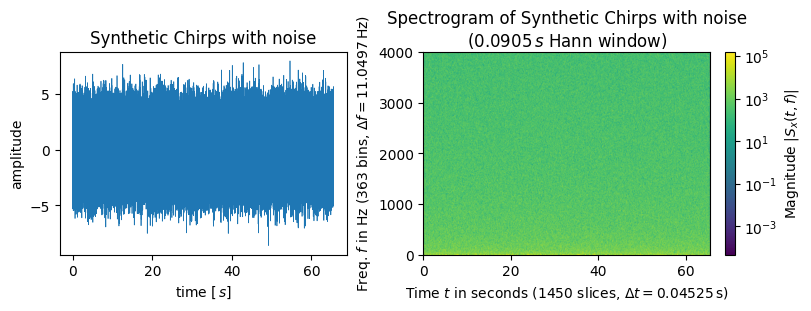

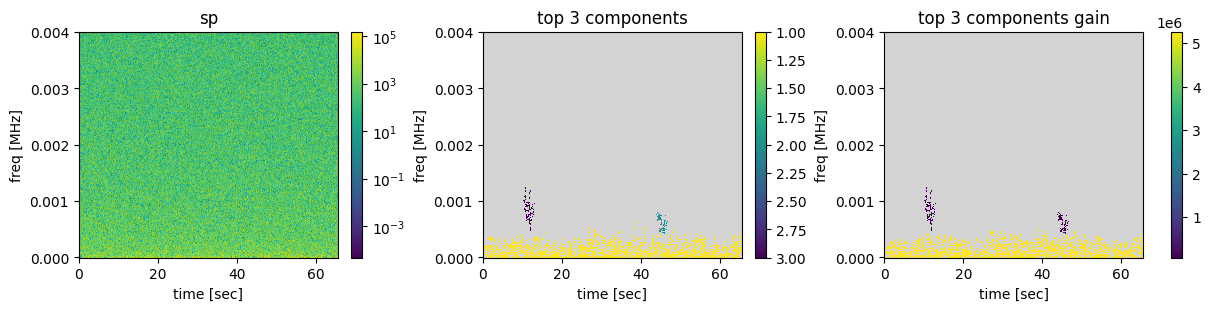

In [52]:
# @title Synthetic data example of max_tree and optimum components using Chirp object and noise
# cell name: example_synthetic_chirp_signal_with_noise
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_synthetic_chirp_signal_with_noise=True

## begin make_example_synthetic_signal
doSignalPlot = True
doSignalSpectrogramPlot = True
vsz,hsz = 3,4

#don't change
nt= 524288 #8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0 #normally 0
noise_std=1 #normally 1


chirps=[]

'''

t0=t[int(nt/16)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp=3.0, t0=t0, t1=t1, f0=0.75*fN, f1=1.0*fN))

t0=t[int(nt/8)]
t1=t[int(nt/8)+int(nt*3/4)-1]
chirps.append(Chirp(amp=3.5, t0=t0, t1=t1, f0=0.5*fN, f1=0.85*fN))
'''

'''
t0= 0  # t[int(nt/5)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp= 4.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.55*fN)) #added to test slope method
'''


sig0 = add_funcsigs(chirps,t)
#sig0 = 0*t

seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = False
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal #uniform #normal #poisson
noise_1 = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )

def color_noise(noise, alpha):
    f = np.fft.rfftfreq(len(noise)); f[0] = f[1] #frequencies of each component
    return np.fft.irfft(np.fft.rfft(noise) / f**(alpha/2), n=len(noise))#real inverse fft of real fft/ freq dependent scaling factor
    #---colored noise function - 0 white, 0.5 pink, 1 brown ----

noise = color_noise(noise_1,0.5) #around alpha of 0.3 errors in detection occur





sig = sig0 + noise #the sythetic noise signal



sigtit='Synthetic Chirps with noise'
from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)

print(sigstft.shape)


if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft


spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

gain_choice= 'avspecdens'
#gain_choice = 'exp(entropy/area)'
#gain_choice = 'skinny'
#gain_choice = '1' #tot intesnity/area
#gain_choice = 'avspecdens_div_freq'
#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice = 'signal_energy_concentration'
gain = self.gain_predefined(gain_choice)
# gain is a matrix which represents the gain at each bin each pixel is apart of
#each pixel which is in the same maxtree bin corresponds to the same gain
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=3 #used to be 10
spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)


## end max_tree_optimimum_features


20 SNR

19.989656582701585 SNR Colored
(363, 1450)


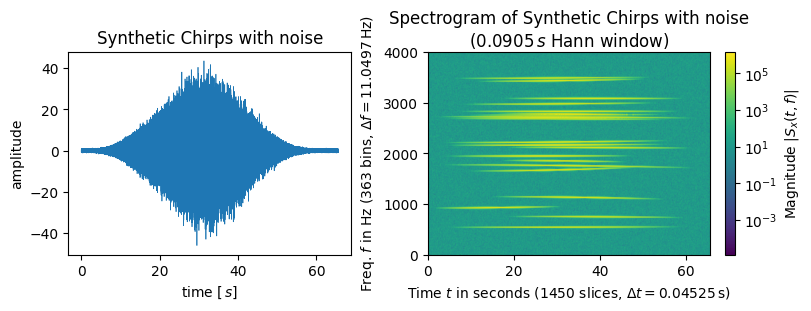

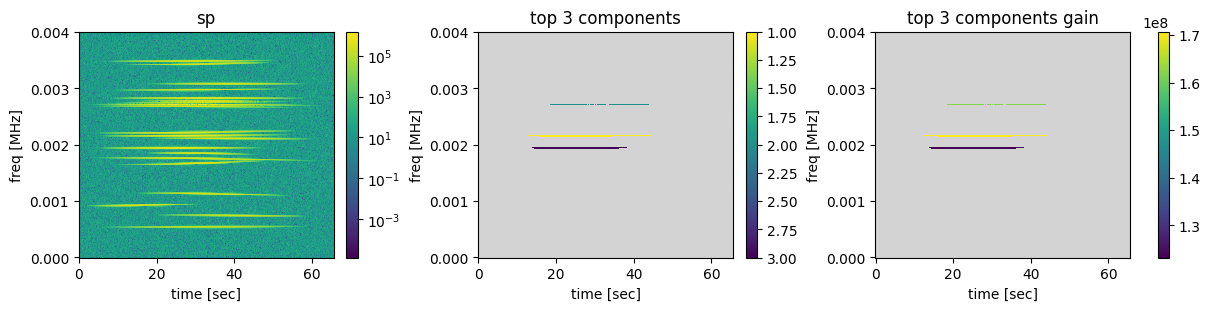

In [31]:
#@title Realistic Synthetic Data
assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_synthetic_chirp_signal_with_noise=True

## begin make_example_synthetic_signal
doSignalPlot = True
doSignalSpectrogramPlot = True
vsz,hsz = 3,4

#don't change
nt= 524288 #8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0 #normally 0
noise_std=1 #normally 1


chirps=[]



#rng = np.random.default_rng(seed=42)   # Same chirps every run
rng = np.random.default_rng()         # New chirps every run

n_chirps = np.random.randint(11, 25)

for i in range(n_chirps):

    # Duration: Gaussian centered at nt/2
    duration = int(rng.normal(loc=nt//1.3, scale=nt/6)) #loc = center of gaussian, scale = stdev of gaussian
    duration = np.clip(duration, nt//16, nt)  # Prevent silly values

    # Random start time
    start_idx = rng.integers(0, nt - duration + 1)
    end_idx = start_idx + duration - 1

    t0 = t[start_idx]
    t1 = t[end_idx]

    # Uniform frequencies
    # Center frequency (where the chirp lives)
    fc = rng.uniform(fN//30, fN//1.05)

    # Frequency sweep size (small on average)
    df = rng.normal(loc=0, scale=0.01*fN) #used to be 0.05fN

    f0 = fc - df/2
    f1 = fc + df/2

    # Keep inside valid range
    f0 = np.clip(f0, 0, fN)
    f1 = np.clip(f1, 0, fN)

    # Gaussian amplitude
    amp = rng.normal(loc=4.0, scale=0.5)

    chirps.append(
        Chirp(
            amp=amp,
            t0=t0,
            t1=t1,
            f0=f0,
            f1=f1
        )
    )



'''
t0= 0  # t[int(nt/5)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp= 4.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.55*fN)) #added to test slope method
'''


sig0 = add_funcsigs(chirps,t)
just_chirps = np.copy(sig0)

SNR = 20
sig_rms = np.sqrt(np.mean(sig0**2))
noise_std = sig_rms / SNR #since the noise rms = noise stdev since mean of the noise is 0


seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = False
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal #uniform #normal #poisson
noise_1 = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )

def color_noise(noise, alpha):
    f = np.fft.rfftfreq(len(noise)); f[0] = f[1] #frequencies of each component
    return np.fft.irfft(np.fft.rfft(noise) / f**(alpha/2), n=len(noise))#real inverse fft of real fft/ freq dependent scaling factor
    #---colored noise function - 0 white, 0.5 pink, 1 brown ----

noise = color_noise(noise_1,0) #around alpha of 0.3 errors in detection occur

sig = sig0 + noise #the sythetic noise signal

SNR_Colored = sig_rms/np.sqrt(np.mean(noise**2))
print(SNR, 'SNR')
print()
print( SNR_Colored, 'SNR Colored')

sigtit='Synthetic Chirps with noise'
from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)

just_chirps_stft = SFT.stft(just_chirps)
just_chirps_fsigstft = SFT.f
just_chirps_tsigstft = SFT.t(just_chirps.size)


print(sigstft.shape)


if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft


spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

gain_choice= 'avspecdens'
#gain_choice = 'exp(entropy/area)'
#gain_choice = 'skinny'
#gain_choice = '1' #tot intesnity/area
#gain_choice = 'avspecdens_div_freq'
#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice = 'signal_energy_concentration'
gain = self.gain_predefined(gain_choice)
# gain is a matrix which represents the gain at each bin each pixel is apart of
#each pixel which is in the same maxtree bin corresponds to the same gain
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=3 #used to be 10
spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)


## end max_tree_optimimum_features


(363, 1450)


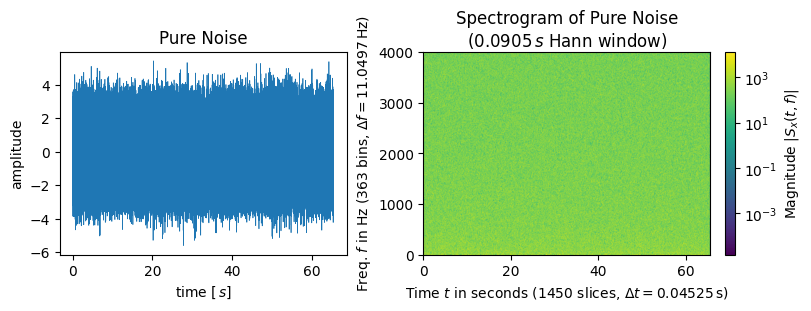

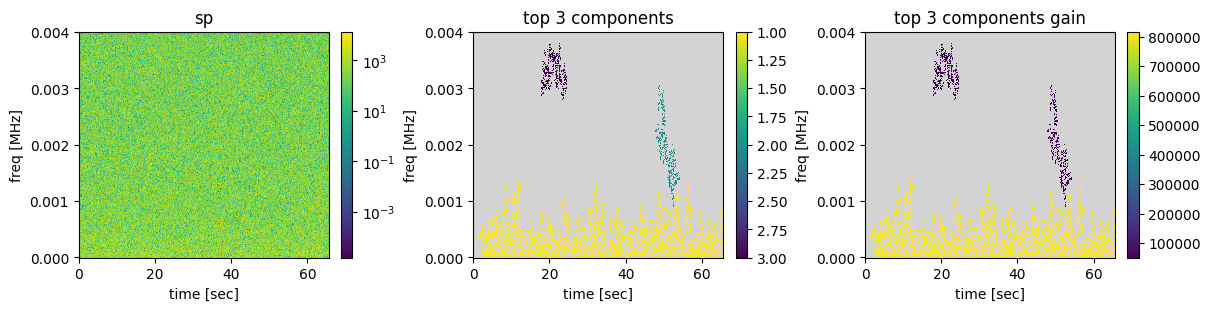

In [42]:
#@title Pure Noise For P-Value
assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_synthetic_chirp_signal_with_noise=True

## begin make_example_synthetic_signal
doSignalPlot = True
doSignalSpectrogramPlot = True
vsz,hsz = 3,4

#don't change
nt= 524288 # power of 2
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0 #normally 0
noise_std=1 #normally 1


seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = False
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal #uniform #normal #poisson
noise_1 = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )

def color_noise(noise, alpha):
    f = np.fft.rfftfreq(len(noise)); f[0] = f[1] #frequencies of each component
    return np.fft.irfft(np.fft.rfft(noise) / f**(alpha/2), n=len(noise))#real inverse fft of real fft/ freq dependent scaling factor
    #---colored noise function - 0 white, 0.5 pink, 1 brown ----

noise = color_noise(noise_1,0.2) #around alpha of 0.3 errors in detection occur

sig = noise #the sythetic noise signal


sigtit='Pure Noise'
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)


print(sigstft.shape)


if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft


spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

gain_choice= 'avspecdens'
#gain_choice = 'exp(entropy/area)'
#gain_choice = 'skinny'
#gain_choice = '1' #tot intesnity/area
#gain_choice = 'avspecdens_div_freq'
#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice = 'signal_energy_concentration'
gain = self.gain_predefined(gain_choice)
# gain is a matrix which represents the gain at each bin each pixel is apart of
#each pixel which is in the same maxtree bin corresponds to the same gain
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=3 #used to be 10
spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)


## end max_tree_optimimum_features

In [ ]:
#@title Gain Slope Critera Test

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----

gain = self.gain_predefined(gain_choice)

#gain_slope_criteria(gain, self): returns - new gain, num of components left, sorted gain array, second deriv, threshold

new_gain, count, sorted_gain, second_deriv, threshold, second_deriv_threshold, index = gain_slope_criteria(self, gain)

new_t = np.linspace(0,len(sorted_gain),len(sorted_gain)) #for plotting purposes

plt.plot(new_t,sorted_gain)
plt.title('Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Gain Value')
plt.scatter(new_t[index], threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot sorted gain values----

plt.plot(new_t, second_deriv)
plt.title('Second Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Second Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot second deriv of sorted gain values----

print(count)
storage = count

for i in range(len(second_deriv)//2):
    count = 0
    if abs(second_deriv[i]) > second_deriv_threshold:
       count = storage
       break
 #----If there are no significant peaks in first half of array then take 0 components i.e. the signal is noise----
 #----If there are significant peaks then ntop = count as normal


mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(new_gain)

vsz, hsz = 3,4
spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=count,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----



In [ ]:
#@title Euler Number Calculator
max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
original_gain = gain.copy()
shape = gain.shape
#----Gets the gain for each pixel (gain matrix), and stores the shape in shape


unique_gain_values, counts = np.unique(gain, return_counts=True)
#----Get unique gain values and their counts----


unique_sorted_rough = np.sort(unique_gain_values)[::-1] #sort unique gain values from highest to lowest
unique_sorted_smooth = unique_sorted_rough #savgol_filter(unique_sorted_rough, window_length=200, polyorder=3) #smooth out sorted unique gain list
new_t = np.linspace(0,len(unique_sorted_smooth),len(unique_sorted_smooth)) #for plotting purposes
slope_unique_sorted = np.gradient(unique_sorted_smooth,new_t) #get the slope at each point
slope_of_slope_unique_sorted = np.gradient(slope_unique_sorted,new_t) #get the slope of the slope at each point
#----sort unique gain values array, smoothing options (I chose not to smooth), define time array as 0-len(unique_sorted_smooth)----
#----get first and second deriv arrays----


index = len(slope_of_slope_unique_sorted) // 2
#----ignore first half of graph to look for later peaks in second deriv----


'''abs_sd = abs(slope_of_slope_unique_sorted)
second_deriv_median = np.median(abs_sd)
median_above_second_deriv_median = np.median(abs_sd[abs_sd > second_deriv_median]) #median of the points above the median
second_deriv_threshold = median_above_second_deriv_median'''
#----setting second deriv threshold as the median of the points above the median, but it didn't work---


length = len(unique_sorted_smooth)
sorted_second_deriv = np.sort(np.abs(slope_of_slope_unique_sorted))[::-1]
last_half = slope_of_slope_unique_sorted[len(slope_of_slope_unique_sorted)//2:]
sorted_last_half = np.sort(np.abs(last_half))[::-1]
#----Sort second deriv array and create sorted array of last half of second deriv array----


#second_deriv_threshold = sorted_second_deriv[length//500]
second_deriv_threshold = sorted_last_half[length//500] #used to be length//1000
#----Gives two choices for second deriv thresh, either 0.02 percent of total array or of last half of array----
#---- Second Deriv Threshold is now being in the 99.8th percentile wrt last half of second deriv array----

key = True
while key:
  if index >= len(slope_unique_sorted) - 1 :
    index = np.argmin(np.abs(slope_of_slope_unique_sorted)) #index to the max second derivative index if we find no such peak in last half
    key = False
  if abs(slope_of_slope_unique_sorted[index]) > second_deriv_threshold:
    key = False
  index += 1
#----index through last half of second deriv array until we find first value which is above, store that index in index----



threshold = unique_sorted_smooth[index]
print('cutoff value:',threshold, ' cutoff time:', new_t[index])
#----use found index to set gain threshold for gain matrix----


for i in range(shape[0]):
  for j in range(shape[1]):
    if gain[i,j] < threshold:
      gain[i,j] = 0
#----set all values below gain to 0----


plt.plot(new_t,unique_sorted_smooth)
plt.title('Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Gain Value')
plt.scatter(new_t[index], threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot sorted gain values----


plt.plot(new_t, slope_unique_sorted)
plt.title('First Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('First Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot first deriv of sorted gain values----


plt.plot(new_t, slope_of_slope_unique_sorted)
plt.title('Second Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Second Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot second deriv of sorted gain values----

mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
#mxgntopfill are the gain values
#mxgnndslabeltopfill are the indices
#code below counts the number of non-zero index, non-repeating index, non-zero gain nodes there are, which is our ntop


modes_iso, count = binary_modes_isolator(gain, mxgnndslabeltopfill)
#isolate modes as binary images, and get the amount of them

modes_iso_filtered = []


for i in range(count):
    if 0 < euler_number(modes_iso[i])[0] < 10:
       modes_iso_filtered.append(modes_iso[i])


gain = mode_remover(gain, modes_iso_filtered)
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

count = len(modes_iso_filtered)

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=count,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----

In [ ]:
#@title Euler Number Then Freq Time Ratio
max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)


modes_iso, count = binary_modes_isolator(gain, mxgnndslabeltopfill)
#isolate modes as binary images, and get the amount of them
print(count,'count')
modes_iso_filtered = []



for i in range(count):
    if -4 < euler_number(modes_iso[i])[0] <= 1  and avg_freq_time_ratio(modes_iso[i]) < 0.3 and tot_pixels(modes_iso[i]) > 50 and avg_freq(modes_iso[i]) > 4:
       modes_iso_filtered.append(modes_iso[i])

for i in range(len(modes_iso_filtered)):
  print(euler_number(modes_iso_filtered[i])[0], avg_freq_time_ratio(modes_iso_filtered[i]), tot_pixels(modes_iso_filtered[i]), avg_freq(modes_iso_filtered[i]))

gain = mode_remover(gain, modes_iso_filtered)
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

count = len(modes_iso_filtered)


'''print(avg_freq_time_ratio(modes_iso_filtered[0]))
print(tot_pixels(modes_iso_filtered[0]))
print(euler_number(modes_iso_filtered[0]))'''


spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=count,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----



KeyboardInterrupt: 

5
[1 1 1 ... 0 0 0] jvirkerfier
11 Outliers 
[0.         1.         0.97936815 1.         0.99316406 0.99222615
 1.         0.99740597 0.9870041  1.         1.         1.        ]


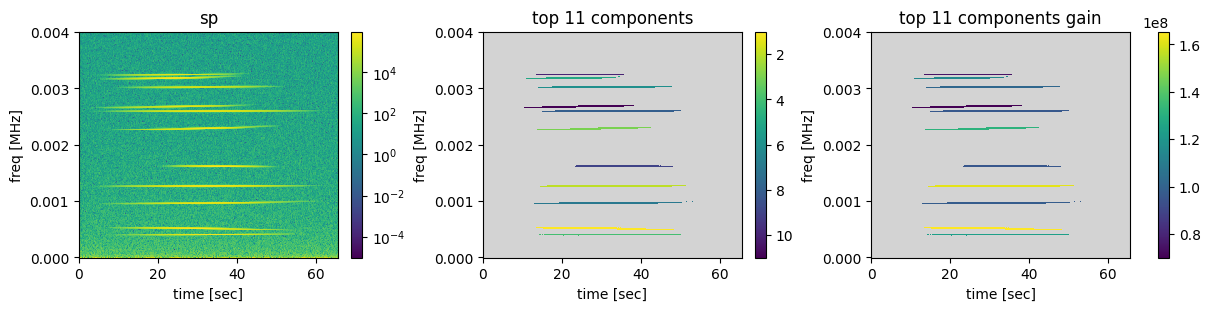

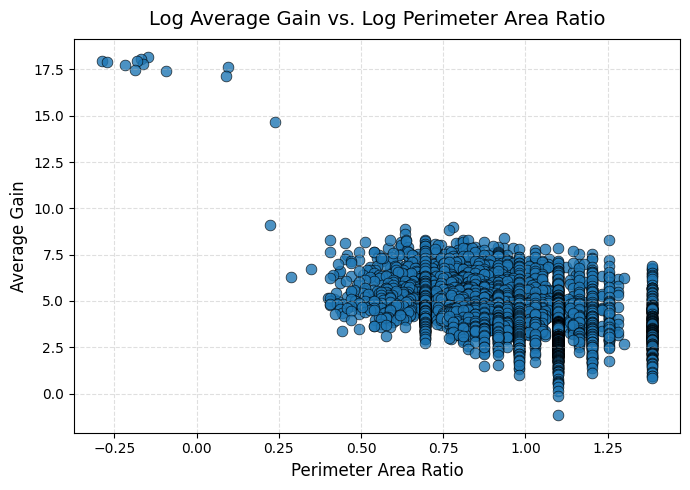

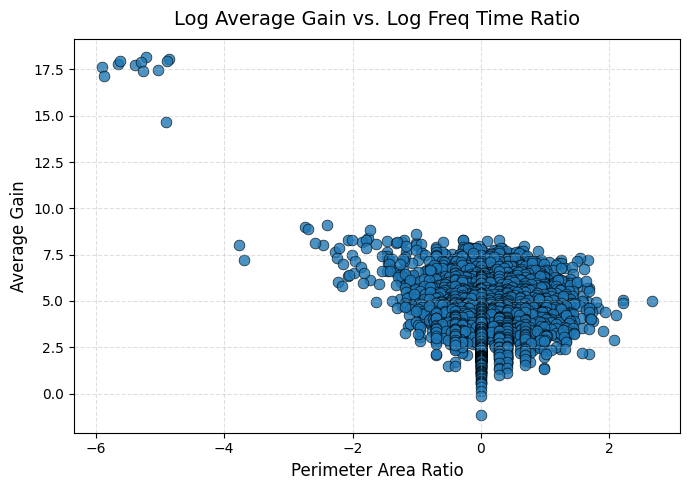

In [ ]:
#@title Efficient Euler Calc

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


just_chirps_stft = SFT.stft(just_chirps)
just_chirps_fsigstft = SFT.f
just_chirps_tsigstft = SFT.t(just_chirps.size)

chirps_sp = np.abs(just_chirps_stft)**2
chirps_fsp = just_chirps_fsigstft
chirps_tsp = just_chirps_tsigstft
chirps_spmxtr=max_tree_cl(chirps_sp,connectivity=2)
#create purely chirps spectrogram for checking overlap score


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

gain_chirps = chirps_spmxtr.gain_predefined(gain_choice)
chirps_mxgnndslabeltopfill,chirps_mxgntopfill = chirps_spmxtr.label_optimummaxattrnode_image_components_with_rank_and_attr(gain_chirps)



'''
[0,0,0,1,0,0],
[0,0,1,1,0,2],
[3,0,0,1,0,2],
[3,3,0,0,0,2]

'''




euler_nums, freq_time, tot_pix, perimeter_area_ratio, simple_freq_time = efficient_euler(mxgnndslabeltopfill)


gain_avg = avg_gain(gain, mxgnndslabeltopfill)

euler_nums = euler_nums[1:]
freq_time = freq_time[1:]
tot_pix = tot_pix[1:]
perimeter_area_ratio = perimeter_area_ratio[1:]
simple_freq_time = simple_freq_time[1:]
gain_avg = gain_avg[1:]


#---Start of Clustering Code---
X = np.column_stack((freq_time, perimeter_area_ratio, gain_avg))
X = StandardScaler().fit_transform(X) #takes the three arrays and makes them all with means of zero and stdevs of around 1, useful for data of different magnitudes

kmeans = KMeans(n_clusters=2, random_state=42, n_init = 10) #used to be n_init = 10
labels = kmeans.fit_predict(X)

optics = OPTICS(
    min_samples=200,
    max_eps=np.inf
)
labels_1 = optics.fit_predict(X)

noise_bool = len(np.unique(labels_1))

print(noise_bool)


#dbscan = DBSCAN(eps=7, min_samples=10)
#labels = dbscan.fit_predict(X)

print(labels,'jvirkerfier')

counts = np.bincount(labels)
outlier_cluster = np.argmin(counts)

outliers = np.where(labels == outlier_cluster)[0]
rejects = np.where(labels != outlier_cluster)[0]

print(len(outliers), 'Outliers ')
#---End of Clustering Code---

'''
freq_time_std = np.std(np.log10(freq_time))
freq_time_mean = np.mean(np.log(freq_time))

perimeter_area_ratio_std = np.std(np.log10(perimeter_area_ratio))
perimeter_area_ratio_mean = np.mean(np.log10(perimeter_area_ratio))


gain_avg_std = np.std(np.log10(gain_avg))
gain_avg_mean = np.mean(np.log10(gain_avg))

print(freq_time_std, freq_time_mean)
print(perimeter_area_ratio_std, perimeter_area_ratio_mean)
print(gain_avg_std, gain_avg_mean)


invalid = np.where(
    (np.log10(freq_time) > freq_time_mean - 3*freq_time_std)|
    (np.log10(freq_time) == 0) |
    (np.log10(perimeter_area_ratio) > perimeter_area_ratio_mean - 3*perimeter_area_ratio_std)|
    (np.log10(gain_avg) < gain_avg_mean + 3*gain_avg_std)|
    (tot_pix < 100)|
    (euler_nums > 1)

)[0]
'''

invalid = rejects

invalid = invalid + 1

gain[np.isin(mxgnndslabeltopfill, invalid)] = 0
mxgnndslabeltopfill[np.isin(mxgnndslabeltopfill,invalid)] = 0


#---Start of Overlap Score Code---
result_unique = np.unique(mxgnndslabeltopfill)
overlap_scores = np.zeros(int(max(result_unique)) + 1)

for label in result_unique:
    if label == 0:
        continue

    overlap = 0

    # Coordinates of this result component
    rows, cols = np.where(mxgnndslabeltopfill == label)

    # Number of pixels belonging to this component
    n_pixels = len(rows)

    # Count how many pixels overlap each chirp
    for i in range(len(rows)):
        if chirps_mxgnndslabeltopfill[int(rows[i]), int(cols[i])] != 0:
            overlap += 1

    score = overlap / n_pixels
    overlap_scores[int(label)] = score

print(overlap_scores)

#---End of Overlap Score Code



freqs = np.arange(shape[0])
t = np.arange(shape[1])



ntop = len(euler_nums) - len(invalid)

if noise_bool == 1:
   ntop = 0


#plot_modes_by_gain(gain, mxgnndslabeltopfill, freqs, t)

kept = np.setdiff1d(np.arange(1, len(euler_nums)), invalid)


'''
print("Component | Euler | Freq/Time | Pixels | Perimeter Area Ratio")
for c in kept:
    print(f"{c:9d} | {euler_nums[c]:5.2f} | {freq_time[c]:9.3f} | {int(tot_pix[c])} | {perimeter_area_ratio[c]} ")

'''


#print(avg_freq_time_ratio(modes_iso_filtered[0]))
#print(tot_pixels(modes_iso_filtered[0]))
#print(euler_number(modes_iso_filtered[0]))
vsz, hsz = 3,4

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain---







'''
plt.figure(figsize=(7,5))
plt.scatter(euler_nums, np.log(gain_avg), s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title("Average Gain vs. Euler Number", fontsize=14, pad=10)
plt.xlabel("Euler Number", fontsize=12)
plt.ylabel("Average Gain", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

'''

plt.figure(figsize=(7,5))
plt.scatter(np.log(perimeter_area_ratio), np.log(gain_avg), s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title("Log Average Gain vs. Log Perimeter Area Ratio", fontsize=14, pad=10)
plt.xlabel("Perimeter Area Ratio", fontsize=12)
plt.ylabel("Average Gain", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(np.log(freq_time), np.log(gain_avg), s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title("Log Average Gain vs. Log Freq Time Ratio", fontsize=14, pad=10)
plt.xlabel("Perimeter Area Ratio", fontsize=12)
plt.ylabel("Average Gain", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



In [57]:
#@title Random Matrices Test

X_array = np.load("synthetic_X.npy", allow_pickle=True)

print(X_array[4].shape)

(5219, 3)


In [43]:
#@title Clustering Test

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----




#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)



'''
[0,0,0,1,0,0],
[0,0,1,1,0,2],
[3,0,0,1,0,2],
[3,3,0,0,0,2]

'''




euler_nums, freq_time, tot_pix, perimeter_area_ratio, simple_freq_time = efficient_euler(mxgnndslabeltopfill)

print(len(euler_nums), 'len of euler nums')



gain_avg = avg_gain(gain, mxgnndslabeltopfill)

euler_nums = euler_nums[1:]
freq_time = freq_time[1:]
tot_pix = tot_pix[1:]
perimeter_area_ratio = perimeter_area_ratio[1:]
simple_freq_time = simple_freq_time[1:]
gain_avg = gain_avg[1:]


#---Start of Clustering Code---
X = np.column_stack((freq_time, perimeter_area_ratio, gain_avg))
X = StandardScaler().fit_transform(X) #takes the three arrays and makes them all with means of zero and stdevs of around 1, useful for data of different magnitudes

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
score = silhouette_score(X, labels)


sc = SigClust()
sc.fit(X, labels=labels)

print(f"p-value: {sc.p_value:.4f}")
print(f"z-score: {sc.z_score:.4f}")

print('s-score: ', score)



'''
optics = OPTICS(
    min_samples=10,
    max_eps=np.inf
)

labels = optics.fit_predict(X)
'''

#dbscan = DBSCAN(eps=7, min_samples=10)
#labels = dbscan.fit_predict(X)

print(len(np.unique(labels)),'jvirkerfier')


'''

counts = np.bincount(labels)
outlier_cluster = np.argmin(counts)

outliers = np.where(labels == outlier_cluster)[0]
rejects = np.where(labels != outlier_cluster)[0]

print(len(outliers), 'Outliers ')
#---End of Clustering Code---

invalid = rejects

invalid = invalid + 1

gain[np.isin(mxgnndslabeltopfill, invalid)] = 0
mxgnndslabeltopfill[np.isin(mxgnndslabeltopfill,invalid)] = 0


#---Start of Overlap Score Code---
result_unique = np.unique(mxgnndslabeltopfill)
overlap_scores = np.zeros(int(max(result_unique)) + 1)

for label in result_unique:
    if label == 0:
        continue

    overlap = 0

    # Coordinates of this result component
    rows, cols = np.where(mxgnndslabeltopfill == label)

    # Number of pixels belonging to this component
    n_pixels = len(rows)

    # Count how many pixels overlap each chirp
    for i in range(len(rows)):
        if chirps_mxgnndslabeltopfill[int(rows[i]), int(cols[i])] != 0:
            overlap += 1

    score = overlap / n_pixels
    overlap_scores[int(label)] = score

print(overlap_scores)

#---End of Overlap Score Code



freqs = np.arange(shape[0])
t = np.arange(shape[1])



ntop = len(euler_nums) - len(invalid)


vsz, hsz = 3,4

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain---





plt.figure(figsize=(7,5))
plt.scatter(np.log(perimeter_area_ratio), np.log(gain_avg), s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title("Log Average Gain vs. Log Perimeter Area Ratio", fontsize=14, pad=10)
plt.xlabel("Perimeter Area Ratio", fontsize=12)
plt.ylabel("Average Gain", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(np.log(freq_time), np.log(gain_avg), s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title("Log Average Gain vs. Log Freq Time Ratio", fontsize=14, pad=10)
plt.xlabel("Perimeter Area Ratio", fontsize=12)
plt.ylabel("Average Gain", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


'''

#Make sure to adapt the p value code to use silhuaette score instead of inertia over quare mean thing


2739 len of euler nums
p-value: 0.3400
z-score: -0.1524
s-score:  0.3337536738211091
2 jvirkerfier


'\n\ncounts = np.bincount(labels)\noutlier_cluster = np.argmin(counts)\n\noutliers = np.where(labels == outlier_cluster)[0]\nrejects = np.where(labels != outlier_cluster)[0]\n\nprint(len(outliers), \'Outliers \')\n#---End of Clustering Code---\n\ninvalid = rejects\n\ninvalid = invalid + 1\n\ngain[np.isin(mxgnndslabeltopfill, invalid)] = 0\nmxgnndslabeltopfill[np.isin(mxgnndslabeltopfill,invalid)] = 0\n\n\n#---Start of Overlap Score Code---\nresult_unique = np.unique(mxgnndslabeltopfill)\noverlap_scores = np.zeros(int(max(result_unique)) + 1)\n\nfor label in result_unique:\n    if label == 0:\n        continue\n\n    overlap = 0\n\n    # Coordinates of this result component\n    rows, cols = np.where(mxgnndslabeltopfill == label)\n\n    # Number of pixels belonging to this component\n    n_pixels = len(rows)\n\n    # Count how many pixels overlap each chirp\n    for i in range(len(rows)):\n        if chirps_mxgnndslabeltopfill[int(rows[i]), int(cols[i])] != 0:\n            overlap += 1\

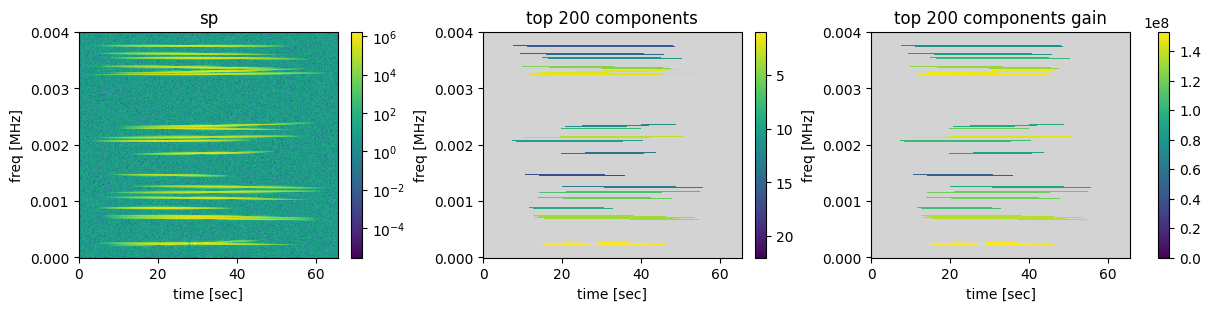

In [ ]:
#@title Just Chirps Zero Test

chirps_spmxtr=max_tree_cl(chirps_sp,connectivity=2)

chirps_mxgnndslabeltopfill,chirps_mxgntopfill = chirps_spmxtr.label_optimummaxattrnode_image_components_with_rank_and_attr(gain_chirps)

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,chirps_mxgnndslabeltopfill,chirps_mxgntopfill,ntop=200,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)


In [ ]:
#@title Automated Invalid Parameters Test

from scipy.stats import ttest_ind


def t_test(data1, data2, equal_var=False):
    """
    Performs a two-sample t-test.

    Parameters
    ----------
    data1, data2 : array-like
        Input datasets.
    equal_var : bool, default=False
        False = Welch's t-test (recommended)
        True = Student's t-test (equal variances)

    Returns
    -------
    t_stat : float
        t-statistic.
    p_value : float
        Two-sided p-value.
    """
    t_stat, p_value = ttest_ind(
        data1,
        data2,
        equal_var=equal_var,
        nan_policy="omit"
    )
    return t_stat, p_value



def std_criteria(gain, gain_stds, freq_time, freq_time_stds, perimeter_area_ratio, perimeter_area_ratio_stds):
    std_gain = np.std(gain)
    std_freq_time = np.std(freq_time)
    std_perimeter_area_ratio = np.std(perimeter_area_ratio)

    mean_gain = np.mean(gain)
    mean_freq_time = np.mean(freq_time)
    mean_perimeter_area_ratio = np.mean(perimeter_area_ratio)

    return

a = np.random.normal(3, 0.5, 15)
b = np.random.normal(10, 2.5, 1000)

tot = np.concatenate((a, b))

std = np.std(tot)
mean = np.mean(tot)

kept = []

for i in range(len(tot)):
    if tot[i] <  mean - 2*std:
       kept.append(tot[i])

print(len(kept))
print()
print(kept)



'''
tot_sort = np.sort(tot)

c = [tot_sort[0]]
d = np.copy(tot_sort[1:])
t_test_array = np.zeros(len(tot_sort) // 2)

for i in range(len(tot_sort) // 2):
    c.append(d[0])
    d = d[1:]
    t_test_array[i] = t_test(c, d)[0]

print(np.max(np.abs(t_test_array)), np.argmax(np.abs(t_test_array)))


print(t_test_array)
'''

29

[np.float64(3.1813557685026397), np.float64(2.3865813122145045), np.float64(2.9379765301406153), np.float64(3.1362380466020285), np.float64(2.420520201304236), np.float64(2.7690442421317796), np.float64(3.778795173921252), np.float64(4.342334778663084), np.float64(2.8130634640443906), np.float64(3.4560669832498796), np.float64(2.7264486763087894), np.float64(3.2420226852078224), np.float64(3.9606227396790774), np.float64(1.9855044885556508), np.float64(2.8439362707586353), np.float64(2.4226892508978874), np.float64(4.222462955847613), np.float64(3.7076789006347743), np.float64(4.4603602998308), np.float64(4.41198427071941), np.float64(3.770876763355883), np.float64(4.651097528814125), np.float64(3.416740750130537), np.float64(2.823222345573761), np.float64(4.526467686553662), np.float64(4.234716731308802), np.float64(4.595052343864522), np.float64(3.6410918548168913), np.float64(3.5163302691911626)]


'\ntot_sort = np.sort(tot)\n\nc = [tot_sort[0]]\nd = np.copy(tot_sort[1:])\nt_test_array = np.zeros(len(tot_sort) // 2)\n\nfor i in range(len(tot_sort) // 2):\n    c.append(d[0])\n    d = d[1:]\n    t_test_array[i] = t_test(c, d)[0]\n\nprint(np.max(np.abs(t_test_array)), np.argmax(np.abs(t_test_array)))\n\n\nprint(t_test_array)\n'

In [ ]:
#@title Overlap Score Test

chirps = np.array([
    [1,1,0,0,0],
    [1,1,0,0,0],
    [0,0,0,2,0],
    [3,0,0,2,0],
    [3,0,0,2,2]
])

result = np.array([
    [1,1,0,0,0],
    [1,0,0,0,0],
    [0,0,0,2,0],
    [3,3,0,2,0],
    [3,0,0,2,2]
])

shape = result.shape

result_unique = np.unique(result)
overlap_scores = np.zeros(result_unique.max() + 1)

for label in result_unique:
    if label == 0:
        continue

    overlap = 0

    # Coordinates of this result component
    rows, cols = np.where(result == label)

    # Number of pixels belonging to this component
    n_pixels = len(rows)

    # Count how many pixels overlap each chirp
    for i in range(len(rows)):
        if chirps[int(rows[i]), int(cols[i])] != 0:
            overlap += 1

    score = overlap / n_pixels
    overlap_scores[label] = score

print(overlap_scores)

'''
We want to take the chirps fft array
Then we want to take the chosen modes i.e. mxgnnodeslabeltopfill

We can then use mxgnnodeslabeltopfill and see if all the modes are there in the chirps array

But how do we do this? Well we can get where the chosen modes are in mxgnndslabeltopfill, then check how many
of the pixels are in the chirps one

For the test above we should get that it's a 100% chance of 1 being real, 100% chance of 2 being real, and 66% chance of 3 being real

Perhaps we can also give an excess score, meaning how many pixels which aren't in the chirp are there

We can then say that low excess score and high P value correspond to a likely mode

'''



[0.         1.         1.         0.66666667]


"\nWe want to take the chirps fft array\nThen we want to take the chosen modes i.e. mxgnnodeslabeltopfill\n\nWe can then use mxgnnodeslabeltopfill and see if all the modes are there in the chirps array\n\nBut how do we do this? Well we can get where the chosen modes are in mxgnndslabeltopfill, then check how many\nof the pixels are in the chirps one\n\nFor the test above we should get that it's a 100% chance of 1 being real, 100% chance of 2 being real, and 66% chance of 3 being real\n\nPerhaps we can also give an excess score, meaning how many pixels which aren't in the chirp are there\n\nWe can then say that low excess score and high P value correspond to a likely mode\n\n"

In [ ]:
#@title Perimeter Calc Test

matrix = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0]
])


def perimeter_calculator(matrix):
    perimeter = 0
    padded = np.pad(matrix, pad_width=1, mode='constant', constant_values=0)
    shape = padded.shape
    Q1 = 1
    Q2 = 1
    QD = 2
    Q3 = 1

    for i in range(shape[0]-1):
        for j in range(shape[1]-1):
            p1 = int(padded[i, j])
            p2 = int(padded[i+1, j])
            p3 = int(padded[i, j+1])
            p4 = int(padded[i+1, j+1])
            p1b = p1 != 0
            p2b = p2 != 0
            p3b = p3 != 0
            p4b = p4 != 0

            count = p1b + p2b + p3b + p4b

            if count == 1:
                perimeter += Q1
            elif count == 3:
                perimeter += Q3
            elif count == 2:
                 if (p1b and p4b) or (p2b and p3b):
                    perimeter += QD
                 else:
                    perimeter += Q2
    return perimeter

def plot_binary_image(matrix, title="Binary Image"):
    rows, cols = matrix.shape
    fig, ax = plt.subplots(figsize=(cols, rows))

    for i in range(rows):
        for j in range(cols):
            is_one = matrix[i, j] == 1
            face = "#3b82f6" if is_one else "#f3f4f6"
            edge = "#1e3a8a" if is_one else "#d1d5db"
            rect = Rectangle((j, rows - i - 1), 1, 1,
                              facecolor=face, edgecolor=edge, linewidth=1.5)
            ax.add_patch(rect)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

plot_binary_image(matrix, title="Binary Image Matrix")

perimeter = perimeter_calculator(matrix)
print(perimeter)





In [ ]:
#@title Quadratic Fit Criteria

from sklearn.decomposition import PCA

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----

gain = self.gain_predefined(gain_choice)

#gain_slope_criteria(gain, self): returns - new gain, num of components left, sorted gain array, second deriv, threshold

new_gain, count, sorted_gain, second_deriv, threshold, second_deriv_threshold, index = gain_slope_criteria(self, gain)

new_t = np.linspace(0,len(sorted_gain),len(sorted_gain)) #for plotting purposes

plt.plot(new_t,sorted_gain)
plt.title('Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Gain Value')
plt.scatter(new_t[index], threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot sorted gain values----

plt.plot(new_t, second_deriv)
plt.title('Second Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Second Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot second deriv of sorted gain values----



'''mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(new_gain)
#mxgntopfill are the gain values
#mxgnndslabeltopfill are the indices
#code below counts the number of non-zero index, non-repeating index, non-zero gain nodes there are, which is our ntop






gain_ravel = new_gain.ravel()
max_tree_indices_ravel = mxgnndslabeltopfill.ravel()
count = 0
count_array = []
for i in range(len(gain_ravel)):
  if gain_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
      count_array.append(max_tree_indices_ravel[i])
      count += 1
#----use optimummaxattr to get mxgnndslabeltopfill which are the max tree indices which point to each parent----
#----count how many unique parent indices are left which aren't 0, and don't have a gain value of 0----

modes_iso = []
for i in range(count):
  modes_iso.append(np.zeros(shape))
  #----Create null matrices to be filled----

for i in range(count):
  for y in range(shape[0]):
    for x in range(shape[1]):
      if mxgnndslabeltopfill[y,x] == count_array[i]:
        modes_iso[i][y,x] = 1
  #----Create binary image for each mode left, copies the image backwards, lets check this out later----



fit_quality_array = []
poly_fit_quality_array = []

for i in range(count):
    y, x = np.where(modes_iso[i] == 1)
    points = np.column_stack((x, y))
    #---Create array of x,y points of currently isolated mode---


    pca = PCA(n_components=2)
    pca.fit(points)
    fit_quality_array.append(pca.explained_variance_)
    # --- linear fit data----


    uv = pca.transform(points)
    u, v = uv[:, 0], uv[:, 1]
    #---u = each points position along dominant direction---
    #---v = each points position along perpendicular direction

    coeffs = np.polyfit(u, v, deg=2)
    v_pred = np.polyval(coeffs, u)
    residuals = v - v_pred
    #---fit to quadratic---

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((v - np.mean(v))**2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    poly_fit_quality_array.append((r_squared))#, rmse, coeffs))
    #seems like modes are around a 0.1 r squared, and noise is quite low
    #lets say if r squared less than 0.03 than it's not a mode

#go through poly_fit_quality_array and see what r sqaured is, if r_squared,
#less than 0.03 or sum then set mode = 0 and redo n count'''


poly_fit_quality_array = quadratic_fit(self, new_gain) #returns quadratic best fit for each mode

print(poly_fit_quality_array)

for i in range(count):
  if poly_fit_quality_array[i] < 0.03:
    modes_iso[i] = np.zeros(shape)
    poly_fit_quality_array[i] = 0


chosen_modes = []
for i in range(count):
    if poly_fit_quality_array[i] != 0:
        mode = np.zeros_like(gain)

        for x in range(shape[0]):
            for y in range(shape[1]):
                if modes_iso[i][x, y] == 1:
                    mode[x, y] = gain[x, y]
        chosen_modes.append(mode)









ntop = len(chosen_modes) #count, make sure to change code to actually run



spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----

In [ ]:
#@title Gain Slope Criteria
from scipy.signal import savgol_filter


max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
#gain_choice = 'exp(entropy/area)'
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#gain_choice = 'avspecdens_div_freq'
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
#----Gets the gain for each pixel (gain matrix), and stores the shape in shape


unique_gain_values, counts = np.unique(gain, return_counts=True)
#----Get unique gain values and their counts----


unique_sorted_rough = np.sort(unique_gain_values)[::-1] #sort unique gain values from highest to lowest
unique_sorted_smooth = unique_sorted_rough #savgol_filter(unique_sorted_rough, window_length=200, polyorder=3) #smooth out sorted unique gain list
new_t = np.linspace(0,len(unique_sorted_smooth),len(unique_sorted_smooth)) #for plotting purposes
slope_unique_sorted = np.gradient(unique_sorted_smooth,new_t) #get the slope at each point
slope_of_slope_unique_sorted = np.gradient(slope_unique_sorted,new_t) #get the slope of the slope at each point
#----sort unique gain values array, smoothing options (I chose not to smooth), define time array as 0-len(unique_sorted_smooth)----
#----get first and second deriv arrays----


index = len(slope_of_slope_unique_sorted) // 2
#----ignore first half of graph to look for later peaks in second deriv----


'''abs_sd = abs(slope_of_slope_unique_sorted)
second_deriv_median = np.median(abs_sd)
median_above_second_deriv_median = np.median(abs_sd[abs_sd > second_deriv_median]) #median of the points above the median
second_deriv_threshold = median_above_second_deriv_median'''
#----setting second deriv threshold as the median of the points above the median, but it didn't work---


length = len(unique_sorted_smooth)
sorted_second_deriv = np.sort(np.abs(slope_of_slope_unique_sorted))[::-1]
last_half = slope_of_slope_unique_sorted[len(slope_of_slope_unique_sorted)//2:]
sorted_last_half = np.sort(np.abs(last_half))[::-1]
#----Sort second deriv array and create sorted array of last half of second deriv array----


#second_deriv_threshold = sorted_second_deriv[length//500]
second_deriv_threshold = sorted_last_half[length//500] #used to be length//1000
#----Gives two choices for second deriv thresh, either 0.02 percent of total array or of last half of array----
#---- Second Deriv Threshold is now being in the 99.8th percentile wrt last half of second deriv array----

key = True
while key:
  if index >= len(slope_unique_sorted) - 1 :
    index = np.argmin(np.abs(slope_of_slope_unique_sorted)) #index to the max second derivative index if we find no such peak in last half
    key = False
  if abs(slope_of_slope_unique_sorted[index]) > second_deriv_threshold:
    key = False
  index += 1
#----index through last half of second deriv array until we find first value which is above, store that index in index----



threshold = unique_sorted_smooth[index]
print('cutoff value:',threshold, ' cutoff time:', new_t[index])
#----use found index to set gain threshold for gain matrix----


for i in range(shape[0]):
  for j in range(shape[1]):
    if gain[i,j] < threshold:
      gain[i,j] = 0
#----set all values below gain to 0----


plt.plot(new_t,unique_sorted_smooth)
plt.title('Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Gain Value')
plt.scatter(new_t[index], threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot sorted gain values----


plt.plot(new_t, slope_unique_sorted)
plt.title('First Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('First Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot first deriv of sorted gain values----


plt.plot(new_t, slope_of_slope_unique_sorted)
plt.title('Second Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Second Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot second deriv of sorted gain values----


mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
#mxgntopfill are the gain values
#mxgnndslabeltopfill are the indices
#code below counts the number of non-zero index, non-repeating index, non-zero gain nodes there are, which is our ntop

gain_ravel = gain.ravel()
max_tree_indices_ravel = mxgnndslabeltopfill.ravel()
count = 0
count_array = []
for i in range(len(gain_ravel)):
  if gain_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
      count_array.append(max_tree_indices_ravel[i])
      count += 1
#----use optimummaxattr to get mxgnndslabeltopfill which are the max tree indices which point to each parent----
#----count how many unique parent indices are left which aren't 0, and don't have a gain value of 0----


for i in range(len(slope_of_slope_unique_sorted)//2):
  ntop = 0
  if abs(slope_of_slope_unique_sorted[i]) > second_deriv_threshold:
    ntop = count
    break
 #----If there are no significant peaks in first half of array then take 0 components i.e. the signal is noise----
 #----If there are significant peaks then ntop = count as normal

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----




In [ ]:
#@title Frequency Spread Criteria
from scipy.signal import savgol_filter


max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
#----Gets the gain for each pixel (gain matrix), and stores the shape in shape


unique_gain_values, counts = np.unique(gain, return_counts=True)
#----Get unique gain values and their counts----


unique_sorted_rough = np.sort(unique_gain_values)[::-1] #sort unique gain values from highest to lowest
unique_sorted_smooth = unique_sorted_rough #savgol_filter(unique_sorted_rough, window_length=200, polyorder=3) #smooth out sorted unique gain list
new_t = np.linspace(0,len(unique_sorted_smooth),len(unique_sorted_smooth)) #for plotting purposes
slope_unique_sorted = np.gradient(unique_sorted_smooth,new_t) #get the slope at each point
slope_of_slope_unique_sorted = np.gradient(slope_unique_sorted,new_t) #get the slope of the slope at each point
#----sort unique gain values array, smoothing options (I chose not to smooth), define time array as 0-len(unique_sorted_smooth)----
#----get first and second deriv arrays----


index = len(slope_of_slope_unique_sorted) // 2
#----ignore first half of graph to look for later peaks in second deriv----


'''abs_sd = abs(slope_of_slope_unique_sorted)
second_deriv_median = np.median(abs_sd)
median_above_second_deriv_median = np.median(abs_sd[abs_sd > second_deriv_median]) #median of the points above the median
second_deriv_threshold = median_above_second_deriv_median'''
#----setting second deriv threshold as the median of the points above the median, but it didn't work---


length = len(unique_sorted_smooth)
sorted_second_deriv = np.sort(np.abs(slope_of_slope_unique_sorted))[::-1]
last_half = slope_of_slope_unique_sorted[len(slope_of_slope_unique_sorted)//2:]
sorted_last_half = np.sort(np.abs(last_half))[::-1]
#----Sort second deriv array and create sorted array of last half of second deriv array----


#second_deriv_threshold = sorted_second_deriv[length//500]
second_deriv_threshold = sorted_last_half[length//500] #used to be length//1000
#----Gives two choices for second deriv thresh, either 0.02 percent of total array or of last half of array----
#---- Second Deriv Threshold is now being in the 99.8th percentile wrt last half of second deriv array----

key = True
while key:
  if index >= len(slope_unique_sorted) - 1 :
    index = np.argmin(np.abs(slope_of_slope_unique_sorted)) #index to the max second derivative index if we find no such peak in last half
    key = False
  if abs(slope_of_slope_unique_sorted[index]) > second_deriv_threshold:
    key = False
  index += 1
#----index through last half of second deriv array until we find first value which is above, store that index in index----



threshold = unique_sorted_smooth[index]
print('cutoff value:',threshold, ' cutoff time:', new_t[index])
#----use found index to set gain threshold for gain matrix----


for i in range(shape[0]):
  for j in range(shape[1]):
    if gain[i,j] < threshold:
      gain[i,j] = 0
#----set all values below gain to 0----


plt.plot(new_t,unique_sorted_smooth)
plt.title('Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Gain Value')
plt.scatter(new_t[index], threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot sorted gain values----


'''plt.plot(new_t, slope_unique_sorted)
plt.show()'''
#----plot first deriv of sorted gain values----


plt.plot(new_t, slope_of_slope_unique_sorted)
plt.title('Second Derivative of Sorted Gain Values')
plt.xlabel('Time (Arbitrary)')
plt.ylabel('Second Derivative')
plt.scatter(new_t[index], second_deriv_threshold, color='red', s=20, zorder=4, label='Threshold')
plt.show()
#----plot second deriv of sorted gain values----


mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
#mxgntopfill are the gain values
#mxgnndslabeltopfill are the indices
#code below counts the number of non-zero index, non-repeating index, non-zero gain nodes there are, which is our ntop

gain_ravel = gain.ravel()
max_tree_indices_ravel = mxgnndslabeltopfill.ravel()
count = 0
count_array = []
for i in range(len(gain_ravel)):
  if gain_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
      count_array.append(max_tree_indices_ravel[i])
      count += 1
#----use optimummaxattr to get mxgnndslabeltopfill which are the max tree indices which point to each parent----
#----count how many unique parent indices are left which aren't 0, and don't have a gain value of 0----


storage = [None] * count
for i in range(count):
    storage[i] = ([10000000000,10000000000], [0,0]) #([min time, min freq], [max time, max freq])

for i in range(len(count_array)):
  for time in range(shape[0]):
    for freq in range(shape[1]):
      if mxgnndslabeltopfill[time,freq] == count_array[i]:
        if time < storage[i][0][0]:
          storage[i][0][0] = time
        if freq < storage[i][0][1]:
          storage[i][0][1] = freq
        if time > storage[i][1][0]:
          storage[i][1][0] = time
        if freq > storage[i][1][1]:
          storage[i][1][1] = freq

freq_spread_num = [None] * count
for i in range(count):
  freq_spread_num[i] = (storage[i][1][1] - storage[i][0][1])/ (storage[i][1][0] - storage[i][0][0]) #spread in freq/spread in time


ntop = count

spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----

In [ ]:
#@title Euler Number Test
#image = np.zeros((50, 40), dtype=int)

E0 = np.array([
[0,0,0,0,0,0,0],
[0,1,1,1,1,1,0],
[0,1,0,0,0,1,0],
[0,1,0,0,0,1,0],
[0,1,1,1,1,1,0],
[0,0,0,0,0,0,0]
]) #E = 0

image = np.array([
[0,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,0],
[0,1,0,1,1,1,0,1,0],
[0,1,0,1,1,1,0,1,0],
[0,1,1,1,1,1,1,1,0],
[0,0,0,0,0,0,0,0,0]
]) #E = -1

E2 = np.array([
[0,0,0,0,0,0,0],
[0,1,1,0,1,1,0],
[0,1,1,0,1,1,0],
[0,0,0,0,0,0,0]
]) #E = 2

E3 = np.array([
[0,0,0,0,0,0,0,0,0],
[0,1,1,0,1,1,0,1,0],
[0,1,1,0,1,1,0,1,0],
[0,0,0,0,0,0,0,0,0]
]) #E = 3

E_neg2 = np.array([
[0,0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,1,1,1,1,1,1,0],
[0,1,0,1,0,1,0,1,0,1,0],
[0,1,1,1,1,1,1,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0,0]
]) #E = -2

image = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,1,1,0,0,0,0],
    [0,0,1,1,1,0,0,0],
    [0,1,1,1,0,0,0,0],
    [0,1,0,1,1,1,0,0],
    [0,1,1,1,0,1,0,0],
    [0,0,1,1,1,1,0,0],
    [0,0,0,0,0,0,0,0]
], dtype=int)

image = np.array([
    [0,0,0,0,0,0,0],
    [0,1,0,0,1,0,0],
    [0,0,1,1,0,1,0],
    [0,1,0,1,0,0,0],
    [0,0,1,0,1,0,0],
    [0,0,0,1,0,1,0],
    [0,0,0,0,0,0,0]
], dtype=int)
shape = image.shape

# Create a centered 20x20 filled square
image[15:35, 10:30] = 1

# Plot
plt.imshow(image, cmap='gray', origin='lower', interpolation='nearest')
plt.xlabel("x")
plt.ylabel("y")
plt.title("20x20 Filled Square")
plt.colorbar(label="Pixel Value")
plt.show()



E_1, euler_counts_1 = euler_number(image)
print(E_1, euler_counts_1)




In [ ]:
#@title Only Quadratic Fit Criteria

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft
spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr
#----Initializes the max tree stuff----


#gain_choice = 'avspecheight'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice='combo_specdens_signal_energy_concentration' #pretty good at telling when signal is just noise
#gain_choice = 'signal_energy_concentration' #works with slope method second best, can't tell if signal is just noise
gain_choice='avspecdens' #works with slope method extremely well, can tell if signal is just white noise
#---Imports differents gains----


gain = self.gain_predefined(gain_choice)
shape = gain.shape
#----Gets the gain for each pixel (gain matrix), and stores the shape in shape


unique_gain_values, counts = np.unique(gain, return_counts=True)
#----Get unique gain values and their counts----


mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
#mxgntopfill are the gain values
#mxgnndslabeltopfill are the indices
#code below counts the number of non-zero index, non-repeating index, non-zero gain nodes there are, which is our ntop

gain_ravel = gain.ravel()
max_tree_indices_ravel = mxgnndslabeltopfill.ravel()
count = 0
count_array = []
for i in range(len(gain_ravel)):
  if gain_ravel[i] != 0 and max_tree_indices_ravel[i] not in count_array and max_tree_indices_ravel[i]!= 0:
      count_array.append(max_tree_indices_ravel[i])
      count += 1
#----use optimummaxattr to get mxgnndslabeltopfill which are the max tree indices which point to each parent----
#----count how many unique parent indices are left which aren't 0, and don't have a gain value of 0----
print(count)
modes_iso = []
for i in range(count):
  modes_iso.append(np.zeros(shape))
  #----Create null matrices to be filled----

for i in range(count):
  for x in range(shape[0]):
    for y in range(shape[1]):
      if mxgnndslabeltopfill[x,y] == count_array[i]:
        modes_iso[i][x,y] = 1
  #----Create binary image for each mode left, copies the image backwards, lets check this out later----




'''fit_quality_array = []
for i in range(count):
  y, x = np.where(modes_iso[i] == 1)
  points = np.column_stack((x,y)) #create array from the x and y coords
  pca = PCA(n_components=2) #initialize pca object
  pca.fit(points)
  fit_quality = pca.explained_variance_[0]/pca.explained_variance_[1]
  fit_quality_array.append(fit_quality)


print(fit_quality_array)'''

fit_quality_array = []
poly_fit_quality_array = []

for i in range(count):
    y, x = np.where(modes_iso[i] == 1)
    points = np.column_stack((x, y))
    #---Create array of x,y points of currently isolated mode---


    pca = PCA(n_components=2)
    pca.fit(points)
    fit_quality_array.append(pca.explained_variance_)
    # --- linear fit data----


    uv = pca.transform(points)
    u, v = uv[:, 0], uv[:, 1]
    #---u = each points position along dominant direction---
    #---v = each points position along perpendicular direction

    coeffs = np.polyfit(u, v, deg=2)
    v_pred = np.polyval(coeffs, u)
    residuals = v - v_pred
    #---fit to quadratic---

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((v - np.mean(v))**2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    poly_fit_quality_array.append((r_squared))#, rmse, coeffs))
    #seems like modes are around a 0.1 r squared, and noise is quite low
    #lets say if r squared less than 0.03 than it's not a mode

#go through poly_fit_quality_array and see what r sqaured is, if r_squared,
#less than 0.03 or sum then set mode = 0 and redo n count


for i in range(count):
  if poly_fit_quality_array[i] < 0.5:
    modes_iso[i] = np.zeros(shape)
  if poly_fit_quality_array[i] ==1 :
    plt.imshow(modes_iso[i], cmap='gray')
    plt.show()

new_count = count
for i in range(count):
  if np.sum(modes_iso[i]) == 0:
    new_count = new_count - 1


ntop = new_count #count
print(poly_fit_quality_array)


spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz),use_LogNorm_for_gain=False)
#----plot spectrogram, top components, and top components gain----

In [ ]:
import numpy as np

# Let's use the existing max_tree object 'spmxtr' from your previous cells
# We will identify pixels belonging to the same component.

image_rav = spmxtr.image.ravel()
parent_rav = spmxtr.P.ravel()

# 1. Identify 'Canonical' representatives
# A node is canonical if it's the root OR its intensity is different from its parent
is_canonical = (image_rav != image_rav[parent_rav])
is_canonical[spmxtr.S[0]] = True # The root is always canonical

# 2. Map every pixel to its canonical representative
# We traverse S to propagate canonical indices downwards
canonical_map = np.arange(parent_rav.size)
for p in spmxtr.S:
    q = parent_rav[p]
    if image_rav[p] == image_rav[q]:
        canonical_map[p] = canonical_map[q]

# Now, pixels with the same value in 'canonical_map' belong to the same Max-Tree component.
print(f"Total pixels: {len(canonical_map)}")
print(f"Unique components (canonical nodes): {np.sum(is_canonical)}")

# Example: Grouping pixel indices by component
from collections import defaultdict
components = defaultdict(list)
for pixel_idx, canonical_idx in enumerate(canonical_map):
    components[canonical_idx].append(pixel_idx)

# Show size of the first 5 components found
for i, (c_idx, pixels) in enumerate(list(components.items())[:5]):
    print(f"Component represented by index {c_idx} has {len(pixels)} pixels.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Choose a gain attribute to define what makes a 'significant' structure
gain_choice = 'avspecdens'
gain = spmxtr.gain_predefined(gain_choice)

# 2. Identify optimum nodes and fill descendants to isolate full modes
# mxgnndslabeltopfill contains the rank (1, 2, 3...) of the component at every pixel belonging to it
mxgnndslabeltopfill, mxgntopfill = spmxtr.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

# 3. Extract unique component IDs (excluding background 0)
unique_components = np.unique(mxgnndslabeltopfill)
unique_components = unique_components[unique_components > 0]

# 4. Store each mode as a binary matrix in a list
binary_modes = []
for comp_id in unique_components:
    # Create a binary mask: 1 if pixel belongs to this mode, else 0
    binary_mask = (mxgnndslabeltopfill == comp_id).astype(int)
    binary_modes.append(binary_mask)

print(f"Isolated {len(binary_modes)} full modes.")

# 5. Visualize the first few isolated modes
n_to_show = min(3, len(binary_modes))
fig, axes = plt.subplots(1, n_to_show, figsize=(12, 4))
if n_to_show == 1: axes = [axes]

for i in range(n_to_show):
    axes[i].imshow(binary_modes[i], cmap='gray', origin='lower')
    axes[i].set_title(f'Mode {i+1} (Isolated)')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# @title analysis of attribute correlations
x=self.peak
y=self.volume/np.exp(self.intensity_entropy)
z=np.exp(self.intensity_entropy)/self.area

plt.scatter(x,y,.1,z)
#plt.xlim([0,500])
#plt.ylim([0,500])
plt.colorbar()


In [ ]:
#@title analysis of attributes along lineage

x=self.peak.ravel()
y=(self.volume/np.exp(self.intensity_entropy)).ravel()
z=(np.exp(self.intensity_entropy)/self.area).ravel()

sl = self.sorted_leaf_P_indices
sl = sl[np.argwhere(self.canonicality.ravel()[sl])]
for i in sl[-100:]:
  p = self.path_to_root_as_P_indices(i)
  plt.plot(self.area.ravel()[p],np.exp(self.intensity_entropy).ravel()[p],'.')


#plt.xlim([0,500])
#plt.ylim([0,200])

In [ ]:
#@title lineage tree plots


'''
def path_to_branchpoint_as_P_indices(self,P_index,next=False):
        """Get path from node to soonest branchpoint as P-indices. if next = True and start is branchpoint, continue to next"""
        if self._image is None: return None
        P_rav=self.P.ravel()
        nc_rav = self.numchildcomponents.ravel()
        def pathfrom(q):
            first = True if next else False
            p = None
            ncp = 0
            while q != p and ncp <= 1:
                yield q
                p = q
                ncp = nc_rav[p] if not first else 1
                first = False
                q = P_rav[p]

        return np.fromiter(pathfrom(P_index),int)

from types import MethodType
self.path_to_branchpoint_as_P_indices = MethodType(path_to_branchpoint_as_P_indices, self)

sl = self.sorted_leaf_P_indices
sl = sl[np.nonzero(self.canonicality.ravel()[sl])]

root = self.S[0]
P_rav = self.P.ravel()
pp = []
for i in sl[-100:]:
  while i != root:
      p = self.path_to_branchpoint_as_P_indices(i,next=True)
      i = p[-1]
      pp.append(p)

x = self.area.ravel()
y = np.exp(self.intensity_entropy).ravel()

pargs = [arg for xy in list(zip([x[p][:] for p in pp],[y[p][:] for p in pp])) for arg in xy]
plt.gca().set_prop_cycle(None)
plt.plot(*pargs)

#p0args = [[arg[0]] for xy in list(zip([x[p][:] for p in pp],[y[p][:] for p in pp])) for arg in xy]
#plt.gca().set_prop_cycle(None)
#plt.plot(*p0args,marker='.')

pn1args = [[arg[-1]] for xy in list(zip([x[p][:] for p in pp],[y[p][:] for p in pp])) for arg in xy]
plt.gca().set_prop_cycle(None)
plt.plot(*pn1args,marker='.')
;
#plt.xlim(xmin=0,xmax=1000)
#plt.ylim(ymin=0,ymax=400)
'''

In [ ]:
a=[([1,2,3],[1,2,3]),([4,5],[2,1])]
[el  for suba in a for el in suba]

In [ ]:
# @title Gain Function Tests
spmaxtreedict = dict(self=self,fsp=fsp,tsp=tsp)
gain_choice='avspecdens'; gain_tit = None
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_choice='signal_energy_concentration'; gain_tit = None
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_choice=np.exp(self.intensity_entropy)/self.area ; gain_tit = 'exp(intensity_entropy)/area'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_choice=self.total_intensity/np.exp(self.intensity_entropy); gain_tit = 'total_intensity/exp(intensity_entropy)'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)


In [ ]:
# @title More Gain Function Tests

spmaxtreedict = dict(self=self,fsp=fsp,tsp=tsp)
gain_tit = None

#gain_choice='intensity_entropy'
#gain_choice='avspecdens'
#gain_choice = 'avspecheight'
#gain_choice = 'kldiv_wresp_uniform_intensity'
#gain_choice = 'neg_kldiv_wresp_uniform_intensity'
#gain_choice = 'log_energy_concentration'
#gain_choice = 'total_intensity'

gain_tit = None
gain_choice = np.where(self.total_intensity,np.log(self.total_intensity),0); gain_tit = 'log_total_intensity'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_tit = None
gain_choice='intensity_entropy'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_tit = None
gain_choice = 'log_energy_concentration'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_tit = None
gain_choice = np.where(self.total_intensity,np.log(self.total_intensity/np.mean(sp[:])),0); gain_tit = 'log_avg_normalized_total_intensity'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)

gain_tit = None
gain_choice=np.exp(self.intensity_entropy) ; gain_tit = 'exp(intensity_entropy)'
show_spec_and_gain_or_attr(spmaxtreedict,gain_choice, gain_attr_tit=gain_tit)


In [ ]:
# @title Statistics of chirp extraction with max-tree optimum components
# cell name: statistics_of_chirp_extraction_with_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
statistics_of_noise_max_tree_optimum_components=True

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
overlap = 0.5


chirps=[]

t0=t[int(nt/16)]
t1=t[int(nt/16)+int(nt*3/4)-1]
chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

t0=t[int(nt/8)]
t1=t[int(nt/8)+int(nt*3/4)-1]
chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

sig0 = add_funcsigs(chirps,t)
sigstft0,fsp,tsp = stft_sig(sig0,win_param='hann',fs=fs,nperseg=nfft,overlap=overlap)
sp0 = np.abs(sigstft0)**2

#ntop=10

useSavedRndGenSeed = True
noise_generator = np.random.default_rng(seed=getSavedRndGenSeed() if useSavedRndGenSeed else None).normal
mk_noise = lambda mn,std,shp: make_noise(mn,std,shp,noise_generator=noise_generator)


noise_mean=0
noise_stds = np.linspace(0,.5,6)

max_tree_cl = Max_Tree
#gain_choice='kldiv_wresp_uniform_intensity' # doesn't work
#gain_choice = 'avspecdens'
#gain_choice = 'avspecheight'
gain_choice='signal_energy_concentration'

ntop = 2
ntrials = 10
resids = np.zeros((len(noise_stds),ntrials))

# save diagnostics for display
Save = True
saved=dict()
CompToSave = (len(noise_stds)-1,0)
toSave = { # key:val of form (iouter,itr):['var1',...])
    (0,0):['sig','sigfilt'],
    CompToSave:['sp','mxgnndslabeltopfill','mxgntopfill'],
  }

for iouter,noise_std in enumerate(noise_stds):
    for itr in range(ntrials):
        noise = mk_noise(noise_mean, noise_std, t.shape)
        sig = sig0 + noise

        sigstftn,_,_,SFT = stft_sig(noise,win_param='hann',fs=fs,nperseg=nfft,overlap=0.5,returnSFT=True)
        sigstft = sigstft0 + sigstftn
        sp = np.abs(sigstft)**2

        self=max_tree_cl(sp,connectivity=2)
        gain = self.gain_predefined(gain_choice)
        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

        filt = ((mxgnndslabeltopfill > 0) & (mxgnndslabeltopfill <= ntop))
        sigstftfilt = sigstft*filt
        sigfilt = SFT.istft(sigstftfilt,k1=nt)
        resids[iouter,itr] = np.sqrt(np.mean(np.abs(sigfilt-sig0)**2))
        if Save and (iouter,itr) in toSave:
            saved[(iouter,itr)] = {vk:globals()[vk] for vk in toSave[(iouter,itr)]}


if Save:
    # display saved diagnostics
    fig, (ax1,ax2) = plt.subplots(2,1,sharex=True)
    ax1.plot(t,saved[(0,0)]['sig'],'r',linewidth=0.5)
    ax1.plot(t,saved[(0,0)]['sigfilt'],'b-.',linewidth=0.5)
    ax2.plot(t,saved[(0,0)]['sigfilt']-saved[(0,0)]['sig'],linewidth=0.5)
    plt.xlim(np.array([0,.5])+0.2)

    fig, ax = plt.subplots()
    stdsig0 = np.sqrt(np.mean(np.abs(sig0)**2))
    ax.plot(noise_stds,resids/stdsig0,'.-')
    ax.set_title('resids vs noise_std')
    ax.set_xlabel('noise_std')
    ax.set_ylabel('resid')
    ax.set_ylim(bottom=0)

    spdict = {'sp':saved[CompToSave]['sp'],'fsp':fsp,'tsp':tsp}
    _ = show_top_components_rank_and_gain(spdict,saved[CompToSave]['mxgnndslabeltopfill'],saved[CompToSave]['mxgntopfill'],ntop=ntop)


In [ ]:
fig,ax = plt.subplots(1,2,layout='constrained')

ax[1].hist(self.image.ravel(),bins='auto',density=True)
plt.yscale('log')
#plt.xscale('log')
;

In [ ]:
# @title max_tree optimum components using just noise
# cell name: example_noise_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
example_noise_max_tree_optimum_components=True

## begin make_example_synthetic_signal
doSignalPlot = False
doSignalSpectrogramPlot = False
vsz,hsz = 3,4

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=int(np.ceil(np.sqrt(nt)))
noise_mean=0
noise_std=1.0

chirps=[]
if False:
    t0=t[int(nt/16)]
    t1=t[int(nt/16)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

    t0=t[int(nt/8)]
    t1=t[int(nt/8)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

    sig0 = add_funcsigs(chirps,t)
    sigtit='Synthetic Chirps with noise'
else:
    sig0 = 0*t
    sigtit='Noise'


seedGlobal=getSavedRndGenSeed()
useSavedRndGenSeed = False
noise_generator = np.random.default_rng(seed=seedGlobal if useSavedRndGenSeed else None).normal
noise = make_noise(noise_mean, noise_std, t.shape, noise_generator=noise_generator )

sig = sig0 + noise

from scipy.signal import ShortTimeFFT
t0=t[0]
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
noverlap=int(nfft/2)

SFT = ShortTimeFFT.from_window(win_param='hann', fs=fs, nperseg=nfft,noverlap=noverlap)
sigstft = SFT.stft(sig)
fsigstft = SFT.f
tsigstft = SFT.t(sig.size)

if doSignalPlot or doSignalSpectrogramPlot:
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    nr,nc = 1,doSignalPlot+doSignalSpectrogramPlot
    fig = plt.figure(figsize=(nc*hsz,nr*vsz),layout='constrained')
    gs = GridSpec(nr,nc, figure=fig)
    ipanel = 0

    if doSignalPlot:
        ax = fig.add_subplot(gs[0,ipanel])
        ipanel+=1
        plt.plot(t,sig,'-',linewidth=0.5)
        plt.title(sigtit,wrap=True)
        plt.xlabel(rf'time [$\,s$]')
        plt.ylabel('amplitude')

    if doSignalSpectrogramPlot:
        from matplotlib.colors import LogNorm
        ax1 = fig.add_subplot(gs[0,ipanel])
        ipanel+=1

        kwextra = {}
        vlimdict = {}
        normfunc = LogNorm
        norm = normfunc(**vlimdict)
        #cmstd = cmapIDL_Standard_Gamma_II()
        #cmap = cmstd
        cmap ='viridis'

        N=nt
        t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
        ax1.set_title(rf"Spectrogram of {sigtit}"+"\n"+rf"({SFT.m_num*SFT.T:g}$\,s$ Hann window)",wrap=True)
        ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
                      rf"$\Delta t = {SFT.delta_t:g}\,$s)",
                ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
                      rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
                xlim=(t_lo, t_hi))

        im1 = ax1.imshow(np.abs(sigstft)**2, origin='lower', aspect='auto',
                        extent=SFT.extent(N), cmap=cmap, norm=norm,**kwextra)
        plotLeg=False
        if (False):
            ##need to define "chirpfreqs" before using.  "chripfreqs" should be chirp frequencies vs t)
            ax1.plot(t, chirpfreqs, 'r--', alpha=.5, label='$f_i(t)$')
            plotLeg=True

        plt.colorbar(im1, label="Magnitude $|S_x(t, f)|$")

        if (False):
            # Shade areas where window slices stick out to the side:
            for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                            (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
                ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
            for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
                ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

        if plotLeg: ax1.legend()

## end make_example_synthetic_signal

## begin max_tree_optimimum_features

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft

spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

gain_choice='avspecdens'
#gain_choice = 'avspecheight'
#gain_choice='signal_energy_concentration'

gain = self.gain_predefined(gain_choice)
mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)

ntop=50
spdict = {'sp':sp,'fsp':fsp,'tsp':tsp}
_  = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=ntop,panelsize=(vsz,hsz))


## end max_tree_optimimum_features

In [ ]:
# @title more plots
fig,ax = plt.subplots(1,2,layout='constrained')

ax[1].hist(self.image.ravel(),bins='auto',density=True)
plt.yscale('log')
#plt.xscale('log')
;

In [ ]:
# @title Statistics of max_tree optimum components using just noise
# cell name: statistics_of_noise_max_tree_optimum_components
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
statistics_of_noise_max_tree_optimum_components=True

nt=8192
dt=1.0/8000.0
t=np.arange(0,nt*dt,dt)
nt=len(t)
dt=t[1]-t[0]
fs=1/dt
fN = fs/2.0
nfft=(int(np.ceil(np.sqrt(nt))) // 2) * 2
overlap = 0.5

noiseonly = True
if not noiseonly:
    chirps=[]

    t0=t[int(nt/16)]
    t1=t[int(nt/16)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=2.0, t0=t0, t1=t1, f0=0.3*fN, f1=0.9*fN))

    t0=t[int(nt/8)]
    t1=t[int(nt/8)+int(nt*3/4)-1]
    chirps.append(Chirp(amp=1.5, t0=t0, t1=t1, f0=0.15*fN, f1=0.7*fN))

    sig0 = add_funcsigs(chirps,t)
else:
    sig0 = 0*t

sigstft0,fsp,tsp = stft_sig(sig0,win_param='hann',fs=fs,nperseg=nfft,overlap=0.5)
sp0 = np.abs(sigstft0)**2

useSavedRndGenSeed = True
noise_generator_core = np.random.default_rng(seed=getSavedRndGenSeed() if useSavedRndGenSeed else None)
noise_generator_type = 'normal'

##not using a global mk_noise. Will have on for each trial, below
#noise_generator = getattr(noise_generator_core,noise_generator_type)
#mk_noise = lambda: make_noise(noise_mean,noise_std,noise_shape,noise_generator=noise_generator)

noise_mean=0
#noise_stds = np.linspace(0,.5,6)
noise_stds = np.array([1.0])
noise_shape = t.shape
nstds = len(noise_stds)

max_tree_cl = Max_Tree
#gain_choice = 'avspecdens'
#gain_choice = 'avspecheight'
gain_choice='signal_energy_concentration'
ntrials = 100#1600

#areas statistics. method relies on integer nature of area values.
import scipy.sparse as sprs
areas = []
area_counts = []

#level statistcs
levels = []
level_hist= []

#max_gain statistics
max_gain_vals = []
max_gain_hist = []

#extents statistics
extents = []
extents_hist= []

#volume statistics
volumes = []
volume_hist = []

#height statistics
heights = []
height_hist = []

#component degrees of freedom statistics
Ndegs = []
Ndeg_hist = []

#component freedom fraction statistics
freefracs = []
freefrac__hist = []

# save diagnostics for display
Save = True
CompToSave = (len(noise_stds)-1,0)
toSave = { # key:val of form (iouter,itr):['var1',...])
  }

Savers = []
maxCompSav = 3
def _(locs = None):
    mxgnndinds = locs['mxgnndinds']
    ret = dict()
    if len(mxgnndinds)  <= maxCompSav:
        cToSave = ['self','gain','mxgnndinds']
        ret = {vk:locs[vk] for vk in cToSave}
    return ret

Savers.append(_)

evalParallelPerformance = False
if evalParallelPerformance:
    import os
    import time

# trial task packaged as function, to allow multiple trials via map semantics
def trial(itr,noise_generator):
    ## the following variables should be defined in an outer scope:
    #    sig0,sigstft0,fs,nfft,overlap # signal (noiseless) and stft parameters
    #    noise_mean,noise_std,noise_shape,noise_generator # parameters for make_noise
    #    Save,iouter,toSave,Savers # controls for saving internal state for debug/examination

    if evalParallelPerformance:
        tmin = time.time() # for performance measurement

    noise = make_noise(noise_mean,noise_std,noise_shape,noise_generator=noise_generator)
    sig = sig0+noise

    sigstftn,_,_,SFT = stft_sig(noise,win_param='hann',fs=fs,nperseg=nfft,overlap=overlap,returnSFT=True)
    sigstft = sigstft0 + sigstftn
    sp = np.abs(sigstft)**2
    self=max_tree_cl(sp,connectivity=2)
    gain = self.gain_predefined(gain_choice)
    mxgnnds = self.maxattrnodes(gain) # Find nodes which are local maxima of gain along lineage.
    mxgnnds = self.optimummaxattrnodes(gain,maxattrnodes=mxgnnds) #prune gain-maximum nodes to leave only nodes with no descencdent having higher gain. has shape of gain, with nonzero values for only surviving nodes
    mxgnndinds = np.flatnonzero(mxgnnds * self.canonicality) # nonzero nodes mxgnnds are the winners of the pruning. get their indices. exclude non-canonical nodes.

    #max_gain statistics
    mxgnvls = gain.ravel()[mxgnndinds]

    #level statistcs
    levs = self.image.ravel()[mxgnndinds]

    #extents satistics
    exts = ravel_vec(self.extents)[mxgnndinds]

    #vol statistics
    vols = self.volume.ravel()[mxgnndinds]

    #height statistics
    hghts = self.height.ravel()[mxgnndinds]

    #degrees of freedom statistics
    Ndgs = np.exp(self.intensity_entropy.ravel()[mxgnndinds])

    #freedom fraction statistics
    frfrcs = Ndgs/self.area.ravel()[mxgnndinds]

    #areas statistics. method relies on integer nature of area values.
    #arcnts.append(sprs.coo_array((np.ones_like(mxgnndinds),(np.zeros_like(mxgnndinds),self.area.ravel()[mxgnndinds]-1)),(1,sp.size)))
    arcnts = sprs.csc_array((np.ones_like(mxgnndinds),(np.zeros_like(mxgnndinds),self.area.ravel()[mxgnndinds]-1)),(1,sp.size))
    arcnts.sum_duplicates() # for any sparse array type
    arcnts.sort_indices() # for csc_array or csr_array only
    ars = self.area.ravel()[mxgnndinds]

    ret = dict(mxgnvls=mxgnvls,arcnts=arcnts,ars=ars,levs=levs,exts=exts,vols=vols,hghts=hghts,Ndgs=Ndgs,frfrcs=frfrcs)
    if Save:
        saves = dict()
        saveKey = (iouter,itr)
        if Save and saveKey in toSave:
            saves.update({vk:globals()[vk] for vk in toSave[saveKey]})
        if Save and len(Savers) > 0:
            lock = list(locals().keys())
            locs={k:locals()[k] for k in lock}
            for s in Savers: saves.update(s(locs=locs))
        if len(saves) > 0: ret['saved'] = {saveKey:saves}

    if evalParallelPerformance:
        tmout = time.time() # for performance measurement
        ret['tm'] = (tmin,tmout)
        ret['pid'] = os.getpid() # for performance measurement

    return ret

timePerformance = False
for iouter,noise_std in enumerate(noise_stds):
    iouter = iouter # needed in "outer scope" by function "trial"

    noise_generators = [getattr(ngc,noise_generator_type) for ngc in noise_generator_core.spawn(ntrials)] # 1 generator per noise trial.  maybe allows speedup in parallel processing of trials

    if evalParallelPerformance:
        tmst = time.time() # for performance measurement

    useParallelProcessing = True  #tests on google colab show no speedup with parallel processing, but keeping it around in case it will help on OMFIT
    nParallel = 16
    if useParallelProcessing:
        from multiprocessing import Pool
        with Pool(nParallel) as pool:
            if timePerformance:
                %time ret_trials = list(pool.starmap(trial,zip(range(ntrials),noise_generators)))
            else:
                ret_trials = list(pool.starmap(trial,zip(range(ntrials),noise_generators)))
    else:
        if timePerformance:
            %time ret_trials = list(map(trial,range(ntrials),noise_generators))
        else:
            ret_trials = list(map(trial,range(ntrials),noise_generators))


    doOldWay = False
    if doOldWay:
        arcnts = []
        ars = []

        mxgnvls = []
        levs = []
        exts = []
        vols = []
        hghts = []

    saved=dict()

    for ret in ret_trials:
        if doOldWay:
            arcnts.append(ret['arcnts'])
            ars.append(ret['ars'])

            mxgnvls.append(ret['mxgnvls'])
            levs.append(ret['levs'])
            exts.append(ret['exts'])
            vols.append(ret['vols'])
            hghts.append(ret['hghts'])

        if Save and 'saved' in ret:
            saved.update(ret.pop('saved'))


    #areas statistics. method relies on integer nature of area values.
    if doOldWay:
        areas.append(ars)
        area_counts.append(sprs.vstack(arcnts))
    else:
        areas.append([ret['ars'] for ret in ret_trials])
        area_counts.append(sprs.vstack([ret['arcnts'] for ret in ret_trials]))


    #max_gain statistics
    if doOldWay:
        max_gain_vals.append(mxgnvls)
        mxgnhist,mxgnedgs = np.histogram(np.concatenate(max_gain_vals[-1]),bins='auto')
        max_gain_hist.append((mxgnhist,mxgnedgs))
    else:
        max_gain_vals.append([ret['mxgnvls'] for ret in ret_trials])
        max_gain_hist.append(np.histogram(np.concatenate(max_gain_vals[-1]),bins='auto'))

    #level statistcs
    if doOldWay:
        levels.append(levs)
        levshist,levsedgs = np.histogram(np.concatenate(levs),bins='auto')
        level_hist.append((levshist,levsedgs))
    else:
        levels.append([ret['levs'] for ret in ret_trials])
        level_hist.append(np.histogram(np.concatenate(levels[-1]),bins='auto'))

    #extents statistics
    if True:
        exts = [ret['exts'] for ret in ret_trials]
        extents.append(exts)
        extsshist,extsedgs = list(zip(*[np.histogram(e,bins='auto') for e in np.concatenate(exts).T])) #note that the "extents" statistic is a 2 element vector, in contrast with area another scalar statistics.  need to handled the vectorness of the statistics here
        extents_hist.append((extsshist,extsedgs))
    else:
        extents.append([ret['exts'] for ret in ret_trials])
        extents_hist.append([np.histogram(e,bins='auto') for e in np.concatenate(extents[-1]).T]) #note that the "extents" statistic is a 2 element vector, in contrast with area another scalar statistics.  need to handled the vectorness of the statistics here


    #volume statistics
    if doOldWay:
        volumes.append(vols)
        volshist,volsedgs = np.histogram(np.concatenate(vols),bins='auto')
        volume_hist.append((volshist,volsedgs))
    else:
        volumes.append([ret['vols'] for ret in ret_trials])
        volume_hist.append(np.histogram(np.concatenate(volumes[-1]),bins='auto'))

    #height statistics
    if doOldWay:
        heights.append(hghts)
        hghtshist,hghtsedgs = np.histogram(np.concatenate(hghts),bins='auto')
        height_hist.append((hghtshist,hghtsedgs))
    else:
        heights.append([ret['hghts'] for ret in ret_trials])
        height_hist.append(np.histogram(np.concatenate(heights[-1]),bins='auto'))


#areas statistics. method relies on integer nature of area values.
area_hist = np.stack([ac.sum(axis=0).ravel() for ac in area_counts],axis=0)
area_prob = area_hist/np.sum(area_hist,axis=1,keepdims=True)

if evalParallelPerformance:
    #load spread on processes
    tmin,tmout = [np.array(t)-tmst for t in list(zip(*[r['tm'] for r in ret_trials]))]
    fig = plt.figure(figsize=(8,4),layout='constrained')
    fig.add_subplot(1,2,1)
    plt.hlines([r['pid'] for r in ret_trials],tmin,tmout)
    plt.xlabel('time (s)')
    plt.ylabel('suprocess id')

    fig.add_subplot(1,2,2)
    tm = np.stack([tmin,tmout],axis=0).ravel()
    incr = np.repeat(np.array([1,-1])[:,np.newaxis],tm.size/2,axis=1).ravel()
    iordtm = np.argsort(tm)
    tm = tm[iordtm]
    incr = incr[iordtm]
    cnt = np.cumsum(incr,)
    plt.plot(tm,cnt)
    plt.xlabel('time (s)')
    plt.ylabel('process count')
    plt.suptitle('processing load')


In [ ]:
# @title Plot statistics of max_tree optimum components using just noise
# cell name: plot_statistics_of_noise_max_tree_optimum_components
# before running, run cell "plot_statistics_of_noise_max_tree_optimum_components"

assert 'statistics_of_noise_max_tree_optimum_components' in locals(), 'must first run cell statistics_of_noise_max_tree_optimum_components'
iouter = nstds-1
#area statistics
fig = plt.figure(layout='constrained')
plt.plot(np.arange(area_prob[iouter].shape[-1])+1,area_prob[iouter].T)
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.ylim([.00001,1])
plt.xlabel('area')
plt.ylabel('probability')
plt.title(f'optimum component area distribution, gain_choice = "{gain_choice}"')

#max_gain statistics
fig = plt.figure(layout='constrained')
plt.stairs(max_gain_hist[iouter][0],max_gain_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
#plt.xlim([1,1000])
#plt.ylim([.00001,1])
plt.xlabel('gain of optimum components')
plt.ylabel('counts')
plt.title(f'optimum component gain distribution, gain_choice = "{gain_choice}"')

#extents statistics
for iext in [0,1]:
    fig = plt.figure(layout='constrained')
    plt.stairs(extents_hist[iouter][0][iext],extents_hist[iouter][1][iext])
    plt.yscale('log')
    plt.xscale('log')
    plt.xlim(xmin=1)
    plt.xlabel(f'extents[{iext}] of optimum components')
    plt.ylabel('counts')
    plt.title(f'optimum component extents distribution, gain_choice = "{gain_choice}"')

#volume statistics
fig = plt.figure(layout='constrained')
plt.stairs(volume_hist[iouter][0],volume_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.xlabel('volume of optimum components')
plt.ylabel('counts')
plt.title(f'optimum component volume distribution, gain_choice = "{gain_choice}"')

#height statistics
fig = plt.figure(layout='constrained')
plt.stairs(height_hist[iouter][0],height_hist[iouter][1])
plt.yscale('log')
plt.xscale('log')
plt.xlim(xmin=1)
plt.xlabel('height of optimum components')
plt.ylabel('counts')

if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 4
    ToShow = [k for k in compssavk if ncompssav[k] > 1]
    ToShow = ToShow[0:min(len(ToShow),maxToShow)]
    for i,kTS in enumerate(ToShow):
        self,gain,mxgnndinds = [compssav[kTS][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        spdict = {'sp':self.image,'fsp':fsp,'tsp':tsp}
        _ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')


In [ ]:
# @title Plot diagnostics statistics of max_tree optimum components using just noise
# cell name: diagnostics_statistics_of_noise_max_tree_optimum_components
# before running, run cell "statistics_of_noise_max_tree_optimum_components"

assert 'statistics_of_noise_max_tree_optimum_components' in locals(), 'must first run cell statistics_of_noise_max_tree_optimum_components'

if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 4
    ToShow = [k for k in compssavk if ncompssav[k] > 1]
    ToShow = ToShow[0:min(len(ToShow),maxToShow)]
    for i,kTS in enumerate(ToShow):
        self,gain,mxgnndinds = [compssav[kTS][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        spdict = {'sp':self.image,'fsp':fsp,'tsp':tsp}
        _ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')

In [ ]:
# @title Top components when there are 3 or few top components
if Save:
    # display saved diagnostics

    compssav = {k:v  for k,v in saved.items() if 'mxgnndinds' in v}
    ncompssav = {k:len(v['mxgnndinds']) for k,v in saved.items() if 'mxgnndinds' in v}
    compssavk = list(compssav.keys())

    maxToShow = 8
    nToShow = min(maxToShow,len(compssavk))

    for i in range(nToShow):
        self,gain,mxgnndinds = [compssav[compssavk[i]][k] for k in ['self','gain','mxgnndinds']]

        mxgnndslabeltopfill,mxgntopfill = self.label_optimummaxattrnode_image_components_with_rank_and_attr(gain)
        spdict = {'sp':self.image,'fsp':fsp,'tsp':tsp}
        _ = show_top_components_rank_and_gain(spdict,mxgnndslabeltopfill,mxgntopfill,ntop=len(mxgnndinds))
        plt.suptitle(f'(iouter,itr) = {compssavk[i]}; nComps = {len(mxgnndinds)}')

In [ ]:
ncomps,ncompslab = np.concatenate([[len(m)]*len(m) for m in max_gain_vals[0]]),'num components'
a,alab = np.concatenate(areas[0]),'areas'
g,glab = np.concatenate(max_gain_vals[0]),'gains'
v,vlab = np.concatenate(volumes[0]),'volumes'
l,llab = np.concatenate(levels[0]),'levels'
h,hlab = np.concatenate(heights[0]),'heights'
eh,ehlab = np.concatenate(extents[0])[:,1],'horizontal extents'
gc,gclab = v/a*eh,'avspecdens'


x,xlab = a,alab
y,ylab = l,llab
c,clab = g,glab

from scipy.stats import rankdata
y,ylab = rankdata(y)/y.size,ylab+' rank'

layout=(2,1)
from itertools import count as count
i=count(1)

fig = plt.figure(layout='constrained')
ax = fig.add_subplot(*layout,next(i))
sc = plt.scatter(x,y,s=.1,c=c)
plt.colorbar(sc,label=clab)#,extend='both')
#plt.clim(vmax=20,vmin=5)
plt.xlabel(xlab)
plt.ylabel(ylab)

ax = fig.add_subplot(*layout,next(i))
sc = plt.scatter(x,y,s=.1,c=c)
plt.colorbar(sc,label=clab)#,extend='both')
#plt.clim(vmax=20,vmin=5)
plt.xlabel(xlab)
plt.ylabel(ylab)

;

In [ ]:
fig,ax = plt.subplots(1,2,layout='constrained')

ax[1].hist(self.image.ravel(),bins='auto',density=True)
plt.yscale('log')
#plt.xscale('log')
;

# Extras

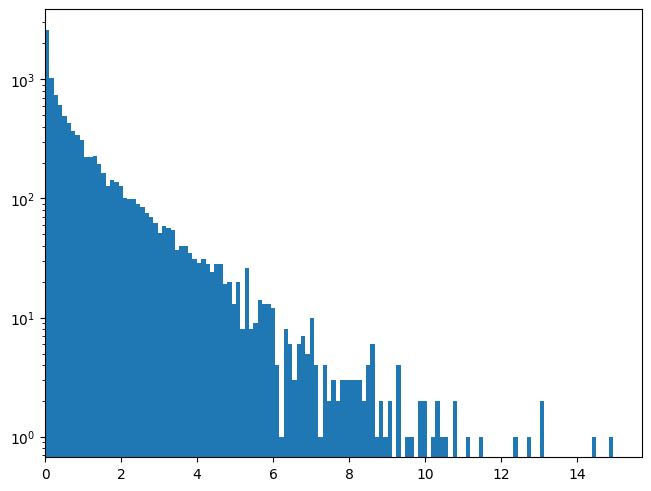

In [ ]:
# @title statistical explorations
import numpy as np
import matplotlib.pyplot as plt

ndegfreedom=1
rng = lambda size: np.random.default_rng().chisquare(df=ndegfreedom,size=size)

fig =  plt.figure(layout='constrained')
ax = fig.add_subplot()
_=ax.hist(rng(10000),bins='auto')
ax.set_xlim(xmin=0)
ax.set_yscale('log')

In [ ]:
#@title stft adapted to mimic ShortTimeFFT

from scipy.signal import stft
from scipy.signal import ShortTimeFFT

In [ ]:
# @title Speed test for various sparse methods of histograming component area statistics
import scipy.sparse as sprs

seed = 12345
rng = np.random.default_rng(seed=seed)

ntrials = 100
sz=10000
thrsh = 900
doareas = True

def build_array(method=0,doareas=False,out=None,rng=rng):

    arcnts = []
    if doareas: areas = np.zeros((ntrials,sz),dtype=int)
    arcntsalt = np.zeros((ntrials,sz),dtype=int)

    for itr in range(ntrials):
        area = rng.integers(0,thrsh+sz,size=sz)
        area = (area-thrsh)*(area >= thrsh)
        if doareas: areas[itr,:] = area


        ind=np.flatnonzero(area)
        temp = np.zeros((sz,))
        np.add.at(temp,area[ind]-1,1)
        arcntsalt[itr,:] = temp

        if method == 0:
            methstr="coo + sum_duplicates approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.coo_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()

        if method == 1:
            methstr="coo + bincount approach"
            ac = np.bincount(area)
            arcnts.append(sprs.coo_array((ac[1:],(np.zeros((len(ac)-1,),dtype=int),np.arange(len(ac)-1))),(1,sz)))
            arcnts[-1].eliminate_zeros()

        if method == 2:
            methstr="csr + sum_duplicates/sort_indices approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.csr_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()
            arcnts[-1].sort_indices()

        if method == 3:
            methstr="csc + sum_duplicates/sort_indices approach"
            ind=np.flatnonzero(area)
            arcnts.append(sprs.csc_array((np.ones_like(ind),(np.zeros_like(ind),area[ind]-1)),(1,sz)))
            arcnts[-1].sum_duplicates()
            arcnts[-1].sort_indices()


    arcnts=sprs.vstack(arcnts)

    if isinstance(out,list) and len(out) == 0:
        out.append(methstr)
        out.append(arcnts)
        out.append(arcnts.sum(axis=0))
        out.append(arcnts.sum(axis=1))
        out.append(arcntsalt)
        if doareas: out.append(areas)

prunN = 100
nmeth = 4
ord = np.arange(nmeth)
np.random.default_rng().shuffle(ord)
outs = [None for i in range(nmeth)]
statsouts = [None for i in range(nmeth)]
for meth in ord:
    rng = np.random.default_rng(seed=seed)
    out = []
    print(meth)
    statsouts[meth] = %timeit -oqn100 build_array(method=meth,doareas=doareas,rng=rng,out=out)
    #statsouts[meth] = %prun -rq for i in range(prunN): build_array(method=meth,doareas=doareas,rng=rng,out=out)
    outs[meth] = out

print('')
import pstats
iord = np.argsort(ord)
acs = []
for meth in range(nmeth):
    methstr,arcnts,arcntssa0,arcntssa1,arcntsalt = outs[meth][0:-1]
    if doareas: areas = outs[meth][-1]
    print("method, sequence: ",methstr,", ",iord[meth])
    if isinstance(statsouts[meth],pstats.Stats):
        statsouts[meth].sort_stats(pstats.SortKey.CUMULATIVE).print_stats(.1)
    else:
        print(statsouts[meth])
    acs.append(arcnts)

allsprs = lambda x,y : (x!=y).count_nonzero() == 0
for meth in range(1,nmeth): print(meth,allsprs(acs[0],acs[meth]))


1
0
2
3

method, sequence:  coo + sum_duplicates approach ,  1
315 ms ± 6.47 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  coo + bincount approach ,  0
210 ms ± 7.37 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  csr + sum_duplicates/sort_indices approach ,  2
282 ms ± 19.2 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
method, sequence:  csc + sum_duplicates/sort_indices approach ,  3
254 ms ± 2.55 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
1 True
2 True
3 True


[-5.00e-02  6.94e-18  5.00e-02  1.00e-01  1.50e-01  2.00e-01  2.50e-01  3.00e-01  3.50e-01  4.00e-01  4.50e-01
  5.00e-01  5.50e-01  6.00e-01  6.50e-01  7.00e-01  7.50e-01  8.00e-01  8.50e-01  9.00e-01  9.50e-01  1.00e+00
  1.05e+00  1.10e+00  1.15e+00]
[ 0.00e+00  2.23e-33 -7.44e-03 -3.82e-02 -6.06e-02  1.17e-01  6.84e-01  3.35e-01 -1.32e+00 -1.08e+00  1.03e+00
  8.13e-01 -7.76e-01 -3.22e-01  7.27e-01  3.72e-01 -2.63e-01 -2.22e-01  4.16e-03  3.82e-02  7.44e-03  0.00e+00
  0.00e+00  0.00e+00  0.00e+00]


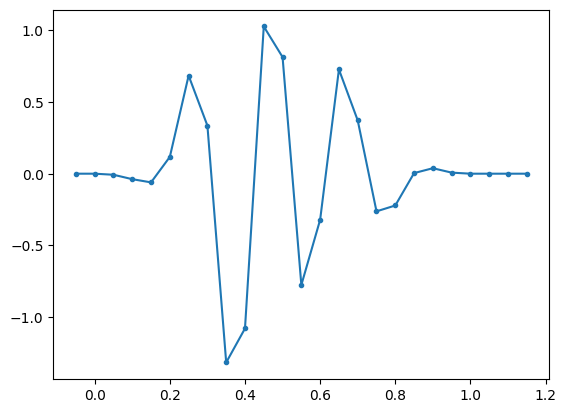

In [ ]:
# @title Demo of Synthetic chirp signals with Chirp objects
# cell name: demo_of_machinery_for_synthetic_chirp_signals_with_noise
# before running, run cell "machinery_and_utilities"

assert 'machinery_and_utilities' in locals(), 'must first run cell machinery_and_utilities'
demo_of_machinery_for_synthetic_chirp_signals_with_noise=True

t=np.linspace(-.1,1.1,25)+.05
chrpd0 = Chirp(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpd1 = Chirp(amp=2.0,t0=0.1,t1=0.9,f0=5.0,f1=3.0,phi=90.0)

chrpds = [chrpd0,chrpd1]
sig = add_funcsigs(chrpds,t)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(t,sig,'.-')

with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)

[-5.00e-02  6.94e-18  5.00e-02  1.00e-01  1.50e-01  2.00e-01  2.50e-01  3.00e-01  3.50e-01  4.00e-01  4.50e-01
  5.00e-01  5.50e-01  6.00e-01  6.50e-01  7.00e-01  7.50e-01  8.00e-01  8.50e-01  9.00e-01  9.50e-01  1.00e+00
  1.05e+00  1.10e+00  1.15e+00]
[ 0.00e+00  2.23e-33 -7.44e-03 -3.82e-02 -3.13e-02  1.18e-01  3.40e-01  3.00e-01 -2.13e-01 -8.08e-01 -7.77e-01
  3.12e-15  7.77e-01  8.08e-01  2.13e-01 -3.00e-01 -3.40e-01 -1.18e-01  3.13e-02  3.82e-02  7.44e-03  0.00e+00
  0.00e+00  0.00e+00  0.00e+00]


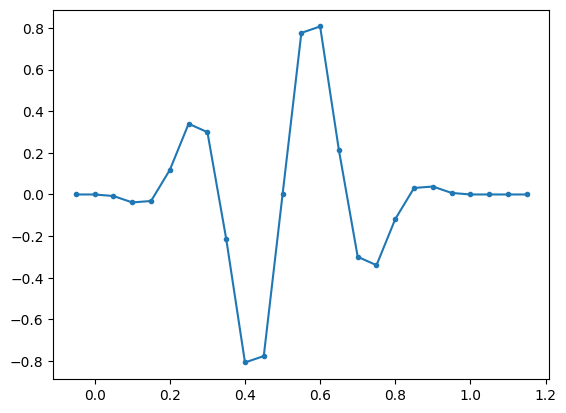

In [ ]:
# @title Legacy synthetic chirp signal machinery
import numpy as np
from scipy.signal import chirp

def blackman_vs_tau(tau):
    """Blackman window vs normalized time (0 <= tau <= 1)
       This gives numpy.blackman(M) == blackman_vs_tau(taus) for taus = (numpy.arange(1-M, M, 2)/(M-1)/2) + 0.5
    """
    return 0.42 + 0.5*np.cos(2*np.pi*(tau-0.5)) + 0.08* np.cos(4*np.pi*(tau-0.5)) #0 <= tau <= 1

def mkchirpdesc(amp=1.0,f0=.25,f1=.75,t0=.1,t1=0.9,phi=0.0,vert0=True):
    return dict(amp=amp,f0=f0,f1=f1,t0=t0,t1=t1,phi=phi,vert0=vert0)

def make_sig(t, chirpdescs = None, phi=0):
    nt=len(t)
    sig=np.zeros((nt,),dtype=float)
    t=np.asarray(t)

    if chirpdescs is None:
        return sig

    for imd,chrp in enumerate(chirpdescs):
        amp,f0,f1,t0,t1,phi,vert0=(chrp[k] for k in ['amp','f0','f1','t0','t1','phi','vert0'])

        it0 = np.searchsorted(t,t0)
        it1 = np.searchsorted(t,t1,side='right')-1
        ntch=it1-it0+1
        if ntch > 0:
            envl=blackman_vs_tau((t[it0:it0+ntch]-t0)/(t1-t0))
            sig[it0:it0+ntch]+=amp*envl*chirp(t[it0:it0+ntch]-t0, f0, t1-t0, f1, method='quadratic', phi=phi, vertex_zero=vert0)
        return sig

import matplotlib.pyplot as plt
t=np.linspace(-.1,1.1,25)+.05
chrpd0 = mkchirpdesc(t0=0.0,t1=1.0,f0=3.0,f1=3.0,phi=90.0)
chrpds = [chrpd0]
sig = make_sig(t,chrpds)
plt.figure()
plt.plot(t,sig,'.-')
with np.printoptions(precision=2, linewidth=120):
    print(t)
    print(sig)

# Scrap Code

In [ ]:
# @title coo_builder (probably useless)
class coo_builder:
    def __init__(self):
        self.data =  []
        self.rowinds =  []
        self.colinds =  []

    def add_data(self,data,inds):
        self.data.append(data)
        self.rowinds.append(inds[0])
        self.colinds.append(inds[1])

    def build_coo(self,shape=None):
        import scipy.sparse as sprs
        return sprs.coo_array(np.concatenate(self.data),(np.concatenate(self.rowinds),np.concatenate(self.colinds)),shape)


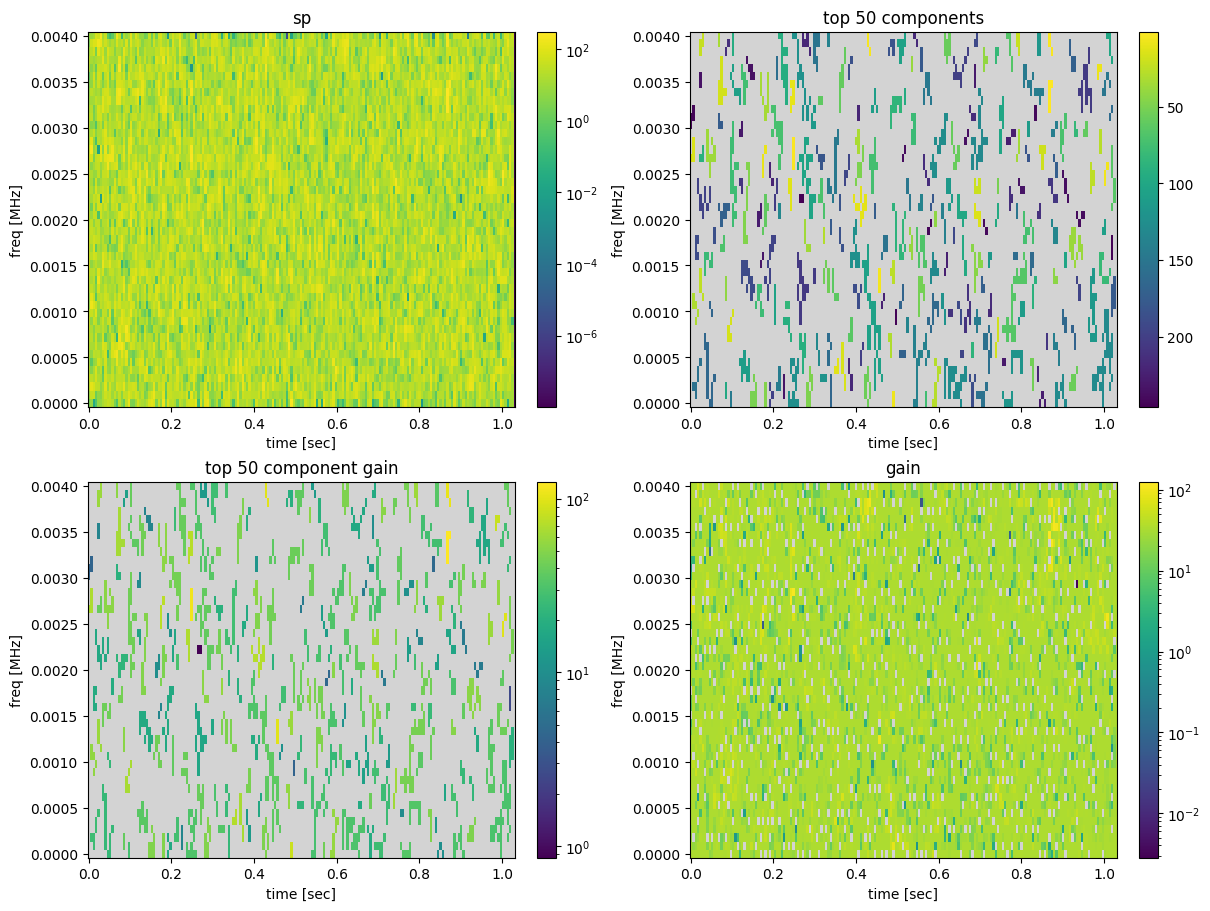

In [ ]:
# @title  max_tree with optimum components

max_tree_cl = Max_Tree
sp = np.abs(sigstft)**2
fsp = fsigstft
tsp = tsigstft

spmxtr=max_tree_cl(sp,connectivity=2)
self=spmxtr

signaltonoise=self.volume/(self.area*self.image)
avspecdens=self.volume/self.area*self.extents[...,1]
avspecheight=self.volume/self.area
specdens_signaltonoise=self.volume*self.extents[...,1]/(self.area*self.image)
volume_growth=self.volume*self.extents[...,1]

gain = avspecheight.copy()

mxgnnds = self.maxattrnodes(gain) # Find nodes which are local maxima of gain along lineage.
mxgnnds = self.optimummaxattrnodes(gain,maxattrnodes=mxgnnds) #prune gain-maximum nodes to leave only nodes with no descencdent having higher gain. has shape of gain, with nonzero values for only surviving nodes
mxgnndinds = np.flatnonzero(mxgnnds) # nonzero nodes mxgnnds are the winners of the pruning. get their indices.
mxgnndinds = mxgnndinds[np.argsort(gain.ravel()[mxgnndinds])] # sort the indices in order for increasing gain.
mxgnndslabeltopfill, mxgnndslabeltop = self.label_image_components(mxgnndinds,range(mxgnndinds.size,0,-1),returnLabledNodes=True) #for each winning node, assign integer rank label to node in matrix, with 1 as highest rank and higher integer for lower rank.  Fill components corresponding to nodes and return filled matrix along with matrix of ranked nodes.
mxgntop=gain*(mxgnndslabeltop > 0) # replace rank in ranked node matrix with gain for node
mxgntopfill = self.fill_components_from_markers(mxgntop) # fill components corresponding to nodes with their gains.

cmstd=cmapIDL_Standard_Gamma_II()
#cmap=cmstd
cmap='viridis'

import matplotlib
CSS4 = matplotlib.colors.CSS4_COLORS

#bgcolor = CSS4['aliceblue']
#bgcolor = CSS4['lightcyan']
bgcolor = CSS4['lightgray']

def zerotonan(arr):
    return np.where(arr == 0,np.nan,arr)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(12,9),layout='constrained')
gs = GridSpec(2,2, figure=fig)


kwextra={}
vlimdict={}


gsc=gs[0,0]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,sp,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title('sp')
ax1,im1,cb=ax,im,cb

gsc=gs[1,0]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,mxgntopfill,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title(f'top {ntop} component gain')
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax2,im2,cb2=ax,im,cb

gsc=gs[0, 1]
norm=None
cmaptab = cmap
if isinstance(cmaptab, str): cmaptab = plt.get_cmap(cmaptab)
cmaptab=cmaptab.reversed()
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,zerotonan(mxgnndslabeltopfill),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmaptab,norm=norm,**kwextra)
ax.set_title(f'top {ntop} components')
cb.ax.invert_yaxis()
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax3,im3,cb3=ax,im,cb

gsc=gs[1, 1]
normfunc=matplotlib.colors.LogNorm
norm=normfunc(**vlimdict)
ax = fig.add_subplot(gsc)
im,cb=specim(tsp,fsp/1e6,zerotonan(gain),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
ax.set_title('gain')
ax.set_facecolor(bgcolor)
ax.sharex(ax1)
ax.sharey(ax1)
ax4,im4,cb4=ax,im,cb


def _():
    gsc=gs[1, 1]
    norm=None
    cmap=cmstd.reversed()
    ax = fig.add_subplot(gsc)
    im,cb=specim(tsp,fsp/1e6,zerotonan(mxgnndslabeltop),xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title(f'top {ntop} max nodes')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    ax4,im4,cb4=ax,im,cb


def _():
    gsc=gs[1, 1]
    norm=None
    cmap=cmstd.reversed()
    ax = fig.add_subplot(gsc)
    im,cb4=specim(tsp,fsp/1e6,mxgnnds,xlabel='time [sec]',ylabel='freq [MHz]',cmap=cmap,norm=norm,**kwextra)
    ax.set_title('all max nodes')
    ax.set_facecolor(bgcolor)
    ax.sharex(ax1)
    ax.sharey(ax1)
    ax4,im4,cb4=ax,im,cb
